<a href="https://colab.research.google.com/github/omarhashem80/us-domestic-flights-delay-prediction/blob/main/Flight_Delays_and_Cancellations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
usdot_flight_delays_path = kagglehub.dataset_download('usdot/flight-delays')

print('Data source import complete.')


Using Colab cache for faster access to the 'flight-delays' dataset.
Data source import complete.


# ✈️ Flight Delay & Cancellation Analytics Platform
### Big Data Project — 2015 U.S. Flight Dataset (DOT / Kaggle)

> **Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)  
> **Size:** ~5.8 million records · 31 features  
> **Tools:** PySpark · Pandas · Scikit-learn · MLlib · Matplotlib · Seaborn · MLxtend

---

## 1. 📌 Introduction & Business Understanding

### 1.1 Problem Statement

The aviation industry faces significant operational and financial challenges due to flight delays and cancellations. These disruptions affect airlines, airports, and passengers, leading to increased operational costs, poor customer satisfaction, and inefficient resource utilization.

This project builds a **data-driven analytics platform** that:
- Predicts whether a flight will be delayed
- Estimates the expected delay duration
- Discovers co-occurring delay patterns
- Segments airports by delay behavior

### 1.2 Business Impact

| Stakeholder | Problem | Platform Benefit |
|---|---|---|
| Airline Ops | Unpredictable delays cause fuel & crew waste | Proactive scheduling adjustments |
| Airport Staff | Congestion hotspots unknown | Identify high-risk windows & routes |
| Booking Platforms | Passengers uninformed | Real-time delay probability scores |
| Revenue Management | Compensation costs | Minimize disruption-driven payouts |

Flight delays cost the U.S. aviation industry **~$28 billion annually** in direct and indirect costs.

### 1.3 Objectives

1. **Delay Prediction (Classification):** Predict whether a flight will be delayed (binary)
2. **Delay Duration Estimation (Regression):** Predict delay duration in minutes
3. **Pattern Discovery:** FP-Growth for co-occurring delay causes; K-Means airport clustering
4. **MapReduce KNN:** Distributed KNN implementation in pseudo-distributed Hadoop mode

### 1.4 Success Metrics

**Classification:** Accuracy, Precision, Recall, F1-Score, ROC-AUC  
**Regression:** RMSE, MAE, R²  
**Business:** Delay uncertainty reduction, scheduling efficiency improvement

---
## 2. 📂 Dataset Description

### 2.1 Data Source

- **Source:** U.S. Department of Transportation (RITA/BTS)
- **Platform:** [Kaggle – 2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays)
- **Files:** `flights.csv` (primary), `airlines.csv`, `airports.csv`
- **Year:** 2015 (full calendar year)

### 2.2 Dataset Overview

| Property | Value |
|---|---|
| Records | ~5.8 million |
| Features | 31 columns |
| Airlines | 14 major U.S. carriers |
| Airports | 322 origin airports |
| File Size | ~574 MB (flights.csv) |

This qualifies as **Big Data** — exceeding typical in-memory Pandas capacity.

### 2.3 Data Dictionary

| Column | Type | Description |
|---|---|---|
| YEAR / MONTH / DAY | int | Flight date components |
| DAY_OF_WEEK | int | 1=Monday … 7=Sunday |
| AIRLINE | str | IATA airline code |
| FLIGHT_NUMBER | int | Carrier flight number |
| TAIL_NUMBER | str | Aircraft registration |
| ORIGIN_AIRPORT | str | Departure airport IATA |
| DESTINATION_AIRPORT | str | Arrival airport IATA |
| SCHEDULED_DEPARTURE | int | HHMM scheduled departure |
| DEPARTURE_TIME | float | Actual departure (HHMM) |
| DEPARTURE_DELAY | float | Delay in minutes (neg=early) |
| TAXI_OUT | float | Taxi-out time (min) |
| WHEELS_OFF | float | Wheels-off time |
| SCHEDULED_TIME | float | Planned flight duration |
| ELAPSED_TIME | float | Actual flight duration |
| AIR_TIME | float | Airborne time |
| DISTANCE | int | Distance in miles |
| WHEELS_ON | float | Wheels-on time |
| TAXI_IN | float | Taxi-in time |
| SCHEDULED_ARRIVAL | int | HHMM scheduled arrival |
| ARRIVAL_TIME | float | Actual arrival |
| ARRIVAL_DELAY | float | Arrival delay (target) |
| DIVERTED | int | 1=diverted |
| CANCELLED | int | 1=cancelled |
| CANCELLATION_REASON | str | A/B/C/D |
| AIR_SYSTEM_DELAY | float | Delay from ATC |
| SECURITY_DELAY | float | Delay from security |
| AIRLINE_DELAY | float | Delay from airline |
| LATE_AIRCRAFT_DELAY | float | Delay from late aircraft |
| WEATHER_DELAY | float | Delay from weather |

### 2.4 Big Data Considerations

- Full dataset (~574 MB) exceeds comfortable Pandas RAM usage
- **PySpark** used for distributed processing
- **Pandas** used on sampled subsets for EDA visualizations
- Memory partitioning and caching strategies applied

---
## 3. ⚙️ Environment Setup & Libraries

### 3.1 Import Libraries

In [2]:
import os
import sys
import warnings
import logging

# Suppress Python warnings
warnings.filterwarnings("ignore")

# Suppress logging noise
# logging.getLogger().setLevel(logging.ERROR)

# LAST RESORT: silence stderr spam
sys.stderr = open(os.devnull, 'w')

import time
import warnings
from collections import defaultdict, Counter

os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--conf spark.ui.showConsoleProgress=false pyspark-shell"

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

logging.getLogger("py4j").setLevel(logging.ERROR)
logging.getLogger("pyspark").setLevel(logging.ERROR)
logging.getLogger("py.warnings").setLevel(logging.ERROR)
logging.getLogger("jupyter_client").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

sns.set_palette('husl')
PALETTE = sns.color_palette('husl', 14)

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.patches as mpatches


from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler as SparkStandardScaler,
    StringIndexer,
    OneHotEncoder
)

from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    RandomForestClassifier as SparkRF,
    GBTClassifier
)

from pyspark.ml.regression import (
    LinearRegression as SparkLinReg,
    RandomForestRegressor as SparkRFReg,
    GBTRegressor
)

from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator
)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.fpm import FPGrowth

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.cluster import KMeans

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

### 3.2 Configuration

In [ ]:
LOCAL_DATA_PATH = "data/"
KAGGLE_DATA_PATH = "/kaggle/input/datasets/organizations/usdot/flight-delays"

In [3]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_DIR = usdot_flight_delays_path
FLIGHTS_PATH = os.path.join(DATA_DIR, 'flights.csv')
AIRLINES_PATH = os.path.join(DATA_DIR, 'airlines.csv')
AIRPORTS_PATH = os.path.join(DATA_DIR, 'airports.csv')

SAMPLE_FRAC = 0.05

TEST_SIZE = 0.2
DELAY_THRESHOLD = 15

spark = (
    SparkSession.builder
    .appName('FlightDelayAnalytics')
    .master('local[*]')
    .config('spark.driver.memory', '4g')
    .config('spark.executor.memory', '4g')
    .config('spark.sql.shuffle.partitions', '50')
    .config('spark.default.parallelism', '8')
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')

print(f'Master: {spark.sparkContext.master}')
print(f'App: {spark.sparkContext.appName}')

Master: local[*]
App: FlightDelayAnalytics


---
## 4. 📥 Data Loading & Initial Inspection

### 4.1 Load Dataset

In [4]:
sdf = spark.read.option('header', 'true').option('inferSchema', 'true').option('nullValue', '').csv(FLIGHTS_PATH)

airlines_df  = pd.read_csv(AIRLINES_PATH)
airports_df  = pd.read_csv(AIRPORTS_PATH)

pdf_sample = sdf.sample(fraction=SAMPLE_FRAC, seed=RANDOM_SEED).toPandas()
print(f'total data: {sdf.count()}')
print(f'sample data: {pdf_sample.shape[0]}')

total data: 5819079
sample data: 290686


### 4.2 Schema & Data Types

In [5]:
sdf.printSchema()

root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable = true)
 |-- ARRIVAL_DELAY: integer (null

In [6]:
pdf_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 290686 non-null  int32  
 1   MONTH                290686 non-null  int32  
 2   DAY                  290686 non-null  int32  
 3   DAY_OF_WEEK          290686 non-null  int32  
 4   AIRLINE              290686 non-null  object 
 5   FLIGHT_NUMBER        290686 non-null  int32  
 6   TAIL_NUMBER          289952 non-null  object 
 7   ORIGIN_AIRPORT       290686 non-null  object 
 8   DESTINATION_AIRPORT  290686 non-null  object 
 9   SCHEDULED_DEPARTURE  290686 non-null  int32  
 10  DEPARTURE_TIME       286462 non-null  float64
 11  DEPARTURE_DELAY      286462 non-null  float64
 12  TAXI_OUT             286329 non-null  float64
 13  WHEELS_OFF           286329 non-null  float64
 14  SCHEDULED_TIME       290686 non-null  int32  
 15  ELAPSED_TIME     

### 4.3 Initial Preview

In [ ]:
pdf_sample.head(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,DL,1560,N3743H,ANC,SEA,45,...,451.0,-24.0,0,0,None,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,OO,7370,N432SW,BJI,MSP,520,...,629.0,9.0,0,0,None,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,OO,5460,N583SW,RDD,SFO,530,...,NaN,NaN,0,1,A,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,B6,1012,N375JB,ORD,BOS,540,...,823.0,-33.0,0,0,None,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,EV,3268,N14998,ATL,IAD,540,...,739.0,14.0,0,0,None,NaN,NaN,NaN,NaN,NaN


In [7]:
pdf_sample.describe().round(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,290686.0,290686.00,290686.00,290686.00,290686.00,290686.00,286462.00,286462.00,286329.00,286329.00,...,290686.00,286144.00,285538.00,290686.00,290686.00,53088.00,53088.00,53088.00,53088.00,53088.00
mean,2015.0,6.52,15.71,3.93,2170.33,1329.81,1335.45,9.33,16.05,1357.21,...,1493.90,1476.86,4.36,0.00,0.02,13.53,0.06,18.66,23.45,2.97
std,0.0,3.41,8.79,1.99,1754.89,483.68,496.31,36.41,8.86,497.88,...,507.42,526.29,38.73,0.05,0.12,27.97,2.50,45.77,43.73,20.34
min,2015.0,1.00,1.00,1.00,1.00,3.00,1.00,-43.00,1.00,1.00,...,1.00,1.00,-81.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2015.0,4.00,8.00,2.00,730.00,917.00,921.00,-5.00,11.00,935.00,...,1110.00,1059.00,-13.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2015.0,7.00,16.00,4.00,1688.00,1325.00,1331.00,-2.00,14.00,1343.00,...,1520.00,1513.00,-5.00,0.00,0.00,2.00,0.00,2.00,3.00,0.00
75%,2015.0,9.00,23.00,6.00,3218.00,1730.00,1739.00,7.00,19.00,1753.00,...,1918.00,1917.00,8.00,0.00,0.00,18.00,0.00,19.00,29.00,0.00
max,2015.0,12.00,31.00,7.00,7438.00,2359.00,2400.00,1179.00,171.00,2400.00,...,2400.00,2400.00,1212.00,1.00,1.00,855.00,440.00,1170.00,1174.00,905.00


---
## 5. 🧹 Data Cleaning

### 5.1 Handling Missing Values

In [8]:
missing = pdf_sample.isnull().sum()
missing_pct = (missing / len(pdf_sample) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
mv_df = mv_df[mv_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
mv_df

,Missing Count,Missing %
CANCELLATION_REASON,286290,98.49
AIR_SYSTEM_DELAY,237598,81.74
SECURITY_DELAY,237598,81.74
WEATHER_DELAY,237598,81.74
AIRLINE_DELAY,237598,81.74
LATE_AIRCRAFT_DELAY,237598,81.74
ARRIVAL_DELAY,5148,1.77
AIR_TIME,5148,1.77
ELAPSED_TIME,5148,1.77
WHEELS_ON,4542,1.56


In [9]:
total_rows = sdf.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
CANCELLATION_REASON,5729195,98.46
SECURITY_DELAY,4755640,81.72
AIR_SYSTEM_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
ARRIVAL_DELAY,105071,1.81
ELAPSED_TIME,105071,1.81
AIR_TIME,105071,1.81
TAXI_IN,92513,1.59


In [10]:
pdf_clean = pdf_sample.copy()

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
pdf_clean[delay_cols] = pdf_clean[delay_cols].fillna(0)

delay_delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
pdf_clean[delay_delay_cols] = pdf_clean[delay_delay_cols].fillna(0)

pdf_clean['CANCELLATION_REASON'] = pdf_clean['CANCELLATION_REASON'].fillna('N')
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN','WHEELS_OFF', 'WHEELS_ON']

for col in time_cols:
    pdf_clean[col] = pdf_clean[col].fillna(0)

sdf_clean = sdf

for col in delay_cols + delay_delay_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

sdf_clean = sdf_clean.fillna({'CANCELLATION_REASON': 'N'})

for col in time_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

In [11]:
pdf_clean.isna().mean() * 100

,0
YEAR,0.000000
MONTH,0.000000
DAY,0.000000
DAY_OF_WEEK,0.000000
AIRLINE,0.000000
FLIGHT_NUMBER,0.000000
TAIL_NUMBER,0.252506
ORIGIN_AIRPORT,0.000000
DESTINATION_AIRPORT,0.000000
SCHEDULED_DEPARTURE,0.000000


In [12]:
total_rows = sdf_clean.count()

missing_expr = [
    F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in sdf.columns
]

missing_df = sdf_clean.select(missing_expr)
missing_pd = missing_df.toPandas().T
missing_pd.columns = ['Missing Count']
missing_pd['Missing %'] = (missing_pd['Missing Count'] / total_rows * 100).round(2)

missing_pd = missing_pd[missing_pd['Missing Count'] > 0]
missing_pd = missing_pd.sort_values('Missing %', ascending=False)

missing_pd

,Missing Count,Missing %
ARRIVAL_TIME,92513,1.59
DEPARTURE_TIME,86153,1.48
TAIL_NUMBER,14721,0.25
SCHEDULED_TIME,6,0.00


### 5.2 Removing Irrelevant Features

In [13]:
for col in pdf_clean.select_dtypes(include='object').columns:
  print(pdf_clean[col].value_counts(normalize=True) * 100,"*"*50,sep='\n')

AIRLINE
WN    21.651542
DL    15.108399
AA    12.428875
OO    10.127767
EV     9.773088
UA     8.954336
MQ     5.052875
B6     4.569880
US     3.387160
AS     2.966087
NK     2.031402
F9     1.569735
HA     1.320325
VX     1.058531
Name: proportion, dtype: float64
**************************************************
TAIL_NUMBER
N488HA    0.071046
N484HA    0.069322
N491HA    0.064149
N489HA    0.063459
N486HA    0.061734
            ...   
N184DN    0.000345
N662NK    0.000345
N7LJAA    0.000345
N7833A    0.000345
N7LKAA    0.000345
Name: proportion, Length: 4742, dtype: float64
**************************************************
ORIGIN_AIRPORT
ATL      5.922886
ORD      4.847155
DFW      4.066587
DEN      3.390600
LAX      3.345878
           ...   
13873    0.000344
14487    0.000344
10581    0.000344
11111    0.000344
11447    0.000344
Name: proportion, Length: 623, dtype: float64
**************************************************
DESTINATION_AIRPORT
ATL      6.008889
ORD      4.988888

In [14]:
pdf_sample.FLIGHT_NUMBER.value_counts(normalize=True) * 100

,proportion
FLIGHT_NUMBER,
469,0.068459
326,0.063643
327,0.063299
667,0.062611
761,0.062267
...,...
6551,0.000344
6719,0.000344
5856,0.000344


In [15]:
# Columns to drop:
#   TAIL_NUMBER  — high cardinality, no predictive value
#   YEAR         — constant (2015)
# NOTE: FLIGHT_NUMBER is KEPT — it is in the approved pre-takeoff feature set.

DROP_COLS = ['TAIL_NUMBER', 'YEAR']

pdf_clean = pdf_clean.drop(columns=DROP_COLS)
sdf_clean = sdf_clean.drop(*DROP_COLS)

print(f'Dropped columns: {DROP_COLS}')
print(f'Remaining columns: {pdf_clean.shape[1]}')


Dropped columns: ['TAIL_NUMBER', 'YEAR']
Remaining columns: 29


In [16]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY'],
      dtype='object')

In [17]:
pdf_check = pdf_clean.copy()

delay_cols = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

# Sum of delay breakdowns (treat NaN as 0 because "no recorded delay component")
pdf_check['BREAKDOWN_SUM'] = pdf_check[delay_cols].fillna(0).sum(axis=1)

# Difference vs actual arrival delay
pdf_check['DIFF'] = pdf_check['ARRIVAL_DELAY'] - pdf_check['BREAKDOWN_SUM']

In [18]:
pdf_check['DIFF'].describe()

,DIFF
count,290686.000000
mean,-6.436626
std,10.192256
min,-81.000000
25%,-13.000000
50%,-5.000000
75%,0.000000
max,14.000000


### 5.3 Fixing Data Types

In [19]:
pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                290686 non-null  int32  
 1   DAY                  290686 non-null  int32  
 2   DAY_OF_WEEK          290686 non-null  int32  
 3   AIRLINE              290686 non-null  object 
 4   FLIGHT_NUMBER        290686 non-null  int32  
 5   ORIGIN_AIRPORT       290686 non-null  object 
 6   DESTINATION_AIRPORT  290686 non-null  object 
 7   SCHEDULED_DEPARTURE  290686 non-null  int32  
 8   DEPARTURE_TIME       286462 non-null  float64
 9   DEPARTURE_DELAY      290686 non-null  float64
 10  TAXI_OUT             290686 non-null  float64
 11  WHEELS_OFF           290686 non-null  float64
 12  SCHEDULED_TIME       290686 non-null  int32  
 13  ELAPSED_TIME         290686 non-null  float64
 14  AIR_TIME             290686 non-null  float64
 15  DISTANCE         

In [20]:
for c in ['AIRLINE','ORIGIN_AIRPORT','DESTINATION_AIRPORT','CANCELLATION_REASON']:
    pdf_clean[c] = pdf_clean[c].astype('category')

pdf_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290686 entries, 0 to 290685
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype   
---  ------               --------------   -----   
 0   MONTH                290686 non-null  int32   
 1   DAY                  290686 non-null  int32   
 2   DAY_OF_WEEK          290686 non-null  int32   
 3   AIRLINE              290686 non-null  category
 4   FLIGHT_NUMBER        290686 non-null  int32   
 5   ORIGIN_AIRPORT       290686 non-null  category
 6   DESTINATION_AIRPORT  290686 non-null  category
 7   SCHEDULED_DEPARTURE  290686 non-null  int32   
 8   DEPARTURE_TIME       286462 non-null  float64 
 9   DEPARTURE_DELAY      290686 non-null  float64 
 10  TAXI_OUT             290686 non-null  float64 
 11  WHEELS_OFF           290686 non-null  float64 
 12  SCHEDULED_TIME       290686 non-null  int32   
 13  ELAPSED_TIME         290686 non-null  float64 
 14  AIR_TIME             290686 non-null  float64 
 15  

### 5.4 Handling Duplicates

In [21]:
pdf_clean.duplicated().sum()

np.int64(0)

In [22]:
n_before = len(pdf_clean)
pdf_clean = pdf_clean.drop_duplicates()
n_dupes   = n_before - len(pdf_clean)
print(f'Duplicate rows removed: {n_dupes:,}')
print(f'Final sample shape: {pdf_clean.shape}')

Duplicate rows removed: 0
Final sample shape: (290686, 29)


In [23]:
n_before = sdf_clean.count()
sdf_clean = sdf_clean.dropDuplicates()
n_after = sdf_clean.count()
n_dupes = n_before - n_after

print(f"Duplicate rows removed: {n_dupes:,}")
print(f"Final sample shape: ({n_after:,}, {len(sdf_clean.columns)})")

Duplicate rows removed: 0
Final sample shape: (5,819,079, 29)


---
## 7. 🏗️ Feature Engineering

> All features are **pre-takeoff only** — information available before the flight departs. No post-departure columns (ARRIVAL_DELAY, AIR_TIME, ELAPSED_TIME, WHEELS_ON, TAXI_IN, delay-breakdown columns) are used in any supervised model.

### 7.1 Pre-Takeoff Feature Set


In [24]:
# ── Feature set (known up to takeoff) ────────────────────────────────────────
# Includes all information available right before wheels-off

FEATURES_AT_TAKEOFF = [
    'MONTH',               # Seasonal pattern
    'DAY',                 # Day of month
    'DAY_OF_WEEK',         # Day of week (Mon=1..Sun=7)

    'SCHEDULED_DEPARTURE', # Planned departure (HHMM)
    'DEPARTURE_TIME',      # Actual departure time (HHMM)
    'DEPARTURE_DELAY',     # Departure delay (minutes)

    'TAXI_OUT',            # Taxi-out duration (minutes)

    'SCHEDULED_TIME',      # Planned flight duration (minutes)
    'DISTANCE',            # Route distance (miles)
    'SCHEDULED_ARRIVAL',   # Planned arrival (HHMM)
    'ARRIVAL_DELAY'
]

# Keep only existing columns (safe guard)
FEATURES_AT_TAKEOFF = [c for c in FEATURES_AT_TAKEOFF if c in pdf_clean.columns]

print(f'Features used ({len(FEATURES_AT_TAKEOFF)}):')
print(FEATURES_AT_TAKEOFF)


# ── Build feature DataFrame ──────────────────────────────────────────────────
pdf_fe = pdf_clean[FEATURES_AT_TAKEOFF].copy()

print(f'\npdf_fe shape: {pdf_fe.shape}')

Features used (11):
['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY']

pdf_fe shape: (290686, 11)


---
## 8. 🔄 Data Preprocessing

### 8.1 Targets & Feature Matrix


In [ ]:
# ── Build model DataFrame (features known up to takeoff) ─────────────────────
pdf_model = pdf_fe.copy()

# ── Targets ──────────────────────────────────────────────────────────────────
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)
pdf_model['DELAY_DURATION'] = pdf_model['ARRIVAL_DELAY'].fillna(0)

# ── Classification features (clean & leakage-free) ───────────────────────────
CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
]

# Keep only existing columns
CLF_COLS = [c for c in CLF_COLS if c in pdf_model.columns]

# ── Optional lightweight feature (safe & useful) ─────────────────────────────
pdf_model['DEP_HOUR'] = (pdf_model['SCHEDULED_DEPARTURE'] // 100).clip(0, 23)
CLF_COLS.append('DEP_HOUR')

# ── Regression features (same as classification for simplicity) ──────────────
REG_COLS = CLF_COLS.copy()

# ── Feature matrices ─────────────────────────────────────────────────────────
X_clf = pdf_model[CLF_COLS].fillna(0)
y_clf = pdf_model['IS_DELAYED']

X_reg = pdf_model[REG_COLS].fillna(0)
y_reg = pdf_model['DELAY_DURATION']

# ── Train/test split ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test, X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_clf, y_clf, X_reg, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

# ── Aliases for downstream cells ─────────────────────────────────────────────
FEATURE_COLS     = CLF_COLS
CLF_FEATURE_COLS = CLF_COLS

# ── Debug prints ─────────────────────────────────────────────────────────────
print(f'Classification features ({len(CLF_COLS)}): {CLF_COLS}')
print(f'Regression    features ({len(REG_COLS)}): {REG_COLS}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Delayed rate — train: {y_clf_train.mean():.3f}  test: {y_clf_test.mean():.3f}')

Classification features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Regression    features (11): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
Train: 232,548  |  Test: 58,138
Delayed rate — train: 0.176  test: 0.176


In [ ]:
# ── Build model DataFrame from pre-takeoff features ──────────────────────────
pdf_model = pdf_fe.copy()

# ── Binary classification target: delayed ≥ 15 min ───────────────────────────
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)

# ── Regression target ────────────────────────────────────────────────────────
pdf_model['DELAY_DURATION'] = pdf_model['ARRIVAL_DELAY'].fillna(0)

# ── STRICT FEATURE SET (ONLY ALLOWED FEATURES) ───────────────────────────────
CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
    'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

# keep only existing columns (safety)
CLF_COLS = [c for c in CLF_COLS if c in pdf_model.columns]

# ── NO DERIVED FEATURES (REMOVED COMPLETELY) ────────────────────────────────
REG_COLS = CLF_COLS.copy()

# ── Feature matrices ──────────────────────────────────────────────────────────
X_clf = pdf_model[CLF_COLS].fillna(0)
y_clf = pdf_model['IS_DELAYED']

X_reg = pdf_model[REG_COLS].fillna(0)
y_reg = pdf_model['DELAY_DURATION']

# ── Train/test split ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_clf_train, y_clf_test, X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_clf, y_clf, X_reg, y_reg,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_clf
)

# ── Aliases for downstream compatibility ─────────────────────────────────────
FEATURE_COLS = CLF_COLS
CLF_FEATURE_COLS = CLF_COLS

# ── Debug print ───────────────────────────────────────────────────────────────
print(f'Classification features ({len(CLF_COLS)}): {CLF_COLS}')
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Delayed rate — train: {y_clf_train.mean():.3f}  test: {y_clf_test.mean():.3f}')

Classification features (10): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL']
Train: 232,548  |  Test: 58,138
Delayed rate — train: 0.176  test: 0.176


### 8.2 Handling Class Imbalance

In [ ]:
print('Before resampling:')
print(f'  Not Delayed: {(y_clf_train==0).sum():,}  |  Delayed: {(y_clf_train==1).sum():,}')

minority_ratio = y_clf_train.mean()
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_bal, y_clf_train_bal = smote.fit_resample(X_train, y_clf_train)

Before resampling:
  Not Delayed: 191,655  |  Delayed: 40,893


### 8.3 PySpark Pipeline Construction (Full Dataset)

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler

# ── Feature set (aligned with pandas) ────────────────────────────────────────
SPARK_CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL',
]

SPARK_CLF_COLS = [c for c in SPARK_CLF_COLS if c in sdf_clean.columns]

# ── Build ML DataFrame ───────────────────────────────────────────────────────
sdf_ml = sdf_clean

# ── Target column ────────────────────────────────────────────────────────────
sdf_ml = sdf_ml.withColumn(
    'IS_DELAYED',
    (F.col('ARRIVAL_DELAY') > DELAY_THRESHOLD).cast('int')
)

# ── Simple derived feature (safe & useful) ───────────────────────────────────
sdf_ml = sdf_ml.withColumn(
    'DEP_HOUR',
    (F.col('SCHEDULED_DEPARTURE') / 100).cast('int')
)

# ── Final feature list ───────────────────────────────────────────────────────
SPARK_ALL_COLS = SPARK_CLF_COLS + ['DEP_HOUR']

# Keep only existing columns
SPARK_ALL_COLS = [c for c in SPARK_ALL_COLS if c in sdf_ml.columns]

# ── Clean data (no nulls in features/target) ─────────────────────────────────
sdf_ml = sdf_ml.dropna(subset=SPARK_ALL_COLS + ['IS_DELAYED'])

# Cast all features to double (required for Spark ML)
for c in SPARK_ALL_COLS:
    sdf_ml = sdf_ml.withColumn(c, F.col(c).cast('double'))

# ── Feature assembler ────────────────────────────────────────────────────────
assembler = VectorAssembler(
    inputCols=SPARK_ALL_COLS,
    outputCol='features',
    handleInvalid='keep'
)

# ── Train/test split ─────────────────────────────────────────────────────────
sdf_train, sdf_test = sdf_ml.randomSplit(
    [1 - TEST_SIZE, TEST_SIZE],
    seed=RANDOM_SEED
)

# Regression uses same data
sdf_reg_train, sdf_reg_test = sdf_train, sdf_test

# ── Debug info ───────────────────────────────────────────────────────────────
n_tr = sdf_train.count()
n_te = sdf_test.count()

print('PySpark pipeline ready')
print(f'  Features  : {SPARK_ALL_COLS}')
print(f'  Train rows: {n_tr:,}')
print(f'  Test  rows: {n_te:,}')

PySpark pipeline ready
  Features  : ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DEP_HOUR']
  Train rows: 4,585,942
  Test  rows: 1,146,978


---
## 9. 🤖 Predictive Modeling

Each sub-section shows **both** the pandas/sklearn version (5% sample) and the PySpark/MLlib version (full 5.8M rows) side-by-side so the scale comparison is explicit.

> **Models used:** Boosting only (HistGradientBoosting / XGBoost style) — no Random Forest or slow SVM/KNN here. KNN appears only in Section 11 (MapReduce demonstration).


### 9.1 Problem Formulation

In [ ]:
print('Classification : predict IS_DELAYED = 1 if ARRIVAL_DELAY > 15 min, else 0')
print('Regression     : predict ARRIVAL_DELAY in minutes (continuous)')
print()
print(f'Features used  : {CLF_COLS}')
print()
print('All features are PRE-TAKEOFF — no post-departure information is used.')
print('DEPARTURE_DELAY is included because it is the actual gate delay,')
print('which is known at the moment the aircraft pushes back.')

Classification : predict IS_DELAYED = 1 if ARRIVAL_DELAY > 15 min, else 0
Regression     : predict ARRIVAL_DELAY in minutes (continuous)

Features used  : ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL']

All features are PRE-TAKEOFF — no post-departure information is used.
DEPARTURE_DELAY is included because it is the actual gate delay,
which is known at the moment the aircraft pushes back.


### 9.2 Evaluation Helpers

In [ ]:
def eval_classifier(name, y_true, y_pred, y_prob=None):
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1'       : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    }

def eval_regressor(name, y_true, y_pred):
    return {
        'Model': name,
        'RMSE' : float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE'  : float(mean_absolute_error(y_true, y_pred)),
        'R²'   : float(r2_score(y_true, y_pred))
    }

clf_results = []
reg_results = []

y_baseline_reg = np.full(len(y_reg_test), y_reg_train.mean())
reg_results.append(eval_regressor('Mean Baseline', y_reg_test, y_baseline_reg))
print(f'Baseline regressor: predict mean = {y_reg_train.mean():.1f} min for every flight')

Baseline regressor: predict mean = 4.3 min for every flight


### 9.3 Classification — Pandas / Sklearn (5% Sample)

> **Boosting models only.** Logistic Regression included as a linear baseline for comparison.


In [ ]:
# X_train_bal = X_train
# y_clf_train_bal = y_clf_train

In [ ]:
X_train_bal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383310 entries, 0 to 383309
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MONTH                383310 non-null  int32  
 1   DAY                  383310 non-null  int32  
 2   DAY_OF_WEEK          383310 non-null  int32  
 3   SCHEDULED_DEPARTURE  383310 non-null  int32  
 4   DEPARTURE_TIME       383310 non-null  float64
 5   DEPARTURE_DELAY      383310 non-null  float64
 6   TAXI_OUT             383310 non-null  float64
 7   SCHEDULED_TIME       383310 non-null  int32  
 8   DISTANCE             383310 non-null  int32  
 9   SCHEDULED_ARRIVAL    383310 non-null  int32  
dtypes: float64(3), int32(7)
memory usage: 19.0 MB


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
NUM_COLS = X_train_bal.columns.to_list()
def build_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    return ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, NUM_COLS)
        ],
        remainder='drop'
    )

In [ ]:
def run_model_pipeline(name, model, param_grid, X_train, y_train, X_test, y_test):

    print(f"\n{'='*30} {name} {'='*30}")

    pipeline = Pipeline([
        ('preprocessing', build_preprocessor()),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fixed_param_grid = {
        f"model__{k}": v for k, v in param_grid.items()
    }

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=fixed_param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f"\nBest CV F1: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

    best_model = search.best_estimator_

    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)

    print("\nTRAIN REPORT")
    print(classification_report(y_train, y_train_pred))

    print("\nTEST REPORT")
    print(classification_report(y_test, y_test_pred))

    return search.best_score_, best_model

In [ ]:
results_clf = {}

results_clf['LR'] = run_model_pipeline(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    {
        'C': [0.01, 0.1, 1, 10]
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)

results_clf['HGB'] = run_model_pipeline(
    "HistGradientBoosting",
    HistGradientBoostingClassifier(random_state=RANDOM_SEED),
    {
        'max_iter': [200],
        'max_depth': [5, 8],
        'learning_rate': [0.05, 0.1],
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)

results_clf['XGB'] = run_model_pipeline(
    "XGBoost",
    XGBClassifier(
        random_state=RANDOM_SEED,
        eval_metric='logloss',
        n_jobs=-1
    ),
    {
        'n_estimators': [200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    X_train_bal, y_clf_train_bal, X_test, y_clf_test
)


============================== Logistic Regression ==============================
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV F1: 0.9169
Best Params: {'model__C': 10}

TRAIN REPORT
              precision    recall  f1-score   support

           0       0.91      0.93      0.92    191655
           1       0.93      0.90      0.92    191655

    accuracy                           0.92    383310
   macro avg       0.92      0.92      0.92    383310
weighted avg       0.92      0.92      0.92    383310


TEST REPORT
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     47915
           1       0.74      0.89      0.80     10223

    accuracy                           0.92     58138
   macro avg       0.86      0.91      0.88     58138
weighted avg       0.93      0.92      0.93     58138


============================== HistGradientBoosting ==============================
Fitting 5 folds for each of 4 candidates, 

In [ ]:
leaderboard = pd.DataFrame(
    {model: [score[0]] for model, score in results_clf.items()},
    index=['Best CV F1']
).T

leaderboard.sort_values(by='Best CV F1', ascending=False)

,Best CV F1
HGB,0.956540
XGB,0.955134
LR,0.916904


### 9.4 Classification — PySpark MLlib (Full 5.8M Rows)

> Same boosting approach, distributed across all cores via Spark. Demonstrates scalability.



Training Spark XGBoost...

Spark XGB trained in 168.7s
  AUC : 0.9645
  F1  : 0.9461
  Acc : 0.9477


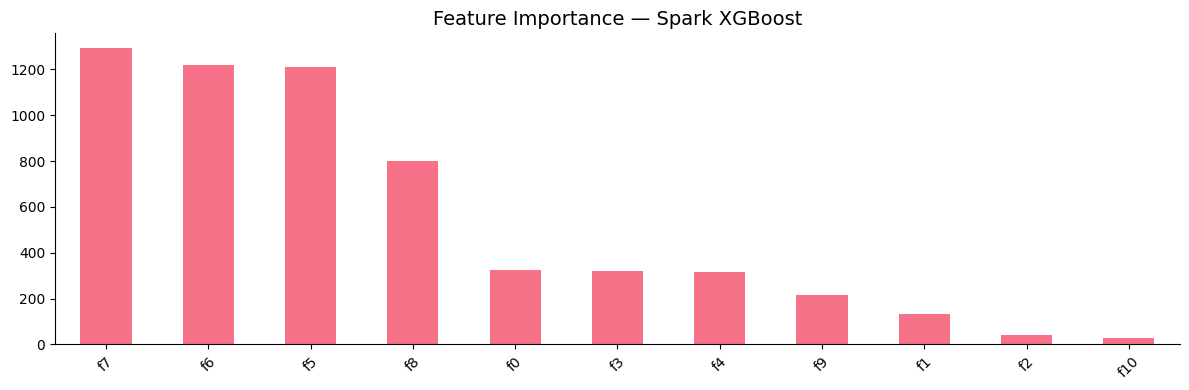

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from xgboost.spark import SparkXGBClassifier


# ── Evaluators ───────────────────────────────────────────────────────────────
bin_eval = BinaryClassificationEvaluator(labelCol='IS_DELAYED', metricName='areaUnderROC')
mc_eval_f1  = MulticlassClassificationEvaluator(labelCol='IS_DELAYED', predictionCol='prediction', metricName='f1')
mc_eval_acc = MulticlassClassificationEvaluator(labelCol='IS_DELAYED', predictionCol='prediction', metricName='accuracy')


# # ─────────────────────────────────────────────────────────────────────────────
# # 1️⃣ Spark GBT (always works)
# # ─────────────────────────────────────────────────────────────────────────────
# spark_gbt_clf = GBTClassifier(
#     featuresCol='features',
#     labelCol='IS_DELAYED',
#     maxIter=100,
#     maxDepth=6,
#     stepSize=0.05,
#     subsamplingRate=0.8,
#     maxBins=64,
#     seed=RANDOM_SEED
# )

# pipeline_gbt = Pipeline(stages=[assembler, spark_gbt_clf])

# print('Training Spark GBT...')
# t0 = time.time()
# spark_gbt_model = pipeline_gbt.fit(sdf_train)
# t_gbt = time.time() - t0

# spark_gbt_preds = spark_gbt_model.transform(sdf_test)

# print(f'\nSpark GBT trained in {t_gbt:.1f}s on {sdf_train.count():,} rows')
# print(f'  AUC : {bin_eval.evaluate(spark_gbt_preds):.4f}')
# print(f'  F1  : {mc_eval_f1.evaluate(spark_gbt_preds):.4f}')
# print(f'  Acc : {mc_eval_acc.evaluate(spark_gbt_preds):.4f}')

# # Feature importance (GBT)
# fi_gbt = pd.Series(
#     spark_gbt_model.stages[-1].featureImportances.toArray(),
#     index=SPARK_ALL_COLS[:len(spark_gbt_model.stages[-1].featureImportances)]
# ).sort_values(ascending=False)

# plt.figure(figsize=(12, 4))
# fi_gbt.plot(kind='bar')
# plt.title('Feature Importance — Spark GBT')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


spark_xgb_clf = SparkXGBClassifier(
    features_col='features',
    label_col='IS_DELAYED',
    num_round=200,
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    seed=RANDOM_SEED,
    num_workers=4
)

pipeline_xgb = Pipeline(stages=[assembler, spark_xgb_clf])

print('\nTraining Spark XGBoost...')
t0 = time.time()
spark_xgb_model = pipeline_xgb.fit(sdf_train)
t_xgb = time.time() - t0

spark_xgb_preds = spark_xgb_model.transform(sdf_test)

print(f'\nSpark XGB trained in {t_xgb:.1f}s')
print(f'  AUC : {bin_eval.evaluate(spark_xgb_preds):.4f}')
print(f'  F1  : {mc_eval_f1.evaluate(spark_xgb_preds):.4f}')
print(f'  Acc : {mc_eval_acc.evaluate(spark_xgb_preds):.4f}')

# Feature importance (SAFE way)
booster = spark_xgb_model.stages[-1].get_booster()
score = booster.get_score(importance_type='weight')

fi_xgb = pd.Series(score).sort_values(ascending=False)

plt.figure(figsize=(12, 4))
fi_xgb.plot(kind='bar')
plt.title('Feature Importance — Spark XGBoost')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9.5 Regression — Pandas / Sklearn (5% Sample)

> Predicts arrival delay minutes using pre-takeoff features + log/interaction transforms.


In [ ]:
X_reg_train.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL'],
      dtype='object')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
def run_reg_pipeline(name, model, param_grid, X_train, y_train, X_test, y_test):

    print(f"\n{'='*30} {name} {'='*30}")

    pipeline = Pipeline([
        ('preprocessing', build_preprocessor()),
        ('model', model)
    ])

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    fixed_param_grid = {
        f"model__{k}": v for k, v in param_grid.items()
    }

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=fixed_param_grid,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    search.fit(X_train, y_train)

    print(f"\nBest CV R²: {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

    best_model = search.best_estimator_

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred  = best_model.predict(X_test)

    # Metrics
    print("\nTRAIN METRICS")
    print(f"R²   : {r2_score(y_train, y_train_pred):.4f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_train, y_train_pred)):.2f}")

    print("\nTEST METRICS")
    print(f"R²   : {r2_score(y_test, y_test_pred):.4f}")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_test_pred)):.2f}")

    return search.best_score_, best_model

In [ ]:
results_reg = {}

# ── Linear Regression ────────────────────────────────────────────────────────
results_reg['LR'] = run_reg_pipeline(
    "Linear Regression",
    LinearRegression(),
    {},
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

# ── HistGradientBoosting ─────────────────────────────────────────────────────
results_reg['HGB'] = run_reg_pipeline(
    "HistGradientBoosting",
    HistGradientBoostingRegressor(random_state=RANDOM_SEED),
    {
        'max_iter': [200],
        'max_depth': [5, 8],
        'learning_rate': [0.05, 0.1],
    },
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)

# ── XGBoost (replacement for GradientBoosting) ───────────────────────────────
results_reg['XGB'] = run_reg_pipeline(
    "XGBoost",
    XGBRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1,
        objective='reg:squarederror'
    ),
    {
        'n_estimators': [200],
        'max_depth': [4, 6],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    X_reg_train, y_reg_train, X_reg_test, y_reg_test
)


============================== Linear Regression ==============================
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best CV R²: 0.9215
Best Params: {}

TRAIN METRICS
R²   : 0.9216
RMSE : 10.78

TEST METRICS
R²   : 0.9198
RMSE : 10.73

============================== HistGradientBoosting ==============================
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV R²: 0.9113
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__max_iter': 200}

TRAIN METRICS
R²   : 0.9277
RMSE : 10.35

TEST METRICS
R²   : 0.9123
RMSE : 11.23

============================== XGBoost ==============================
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV R²: 0.9187
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}

TRAIN METRICS
R²   : 0.9347
RMSE : 9.84

TEST METRICS
R²   : 0.9176
RMSE : 10.88


### 9.6 Regression — PySpark MLlib (Full 5.8M Rows)


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F
import time

from xgboost.spark import SparkXGBRegressor   # ✅ FIX: correct import

# ─────────────────────────────────────────────────────────────────────────────
# 1️⃣ Regression target
# ─────────────────────────────────────────────────────────────────────────────
sdf_reg_train2 = sdf_train.withColumn(
    'DELAY_DURATION',
    F.col('ARRIVAL_DELAY').cast('double')
)

sdf_reg_test2 = sdf_test.withColumn(
    'DELAY_DURATION',
    F.col('ARRIVAL_DELAY').cast('double')
)

sdf_reg_train2 = sdf_reg_train2.dropna(subset=['DELAY_DURATION'])
sdf_reg_test2  = sdf_reg_test2.dropna(subset=['DELAY_DURATION'])

# ─────────────────────────────────────────────────────────────────────────────
# 2️⃣ Random Forest Regressor (baseline fast Spark model)
# ─────────────────────────────────────────────────────────────────────────────
spark_rf_reg = RandomForestRegressor(
    featuresCol='features',
    labelCol='DELAY_DURATION',
    numTrees=100,
    maxDepth=10,
    seed=RANDOM_SEED
)

pipeline_rf_reg = Pipeline(stages=[assembler, spark_rf_reg])

# ─────────────────────────────────────────────────────────────────────────────
# 3️⃣ Spark XGBoost Regressor (stronger model)
# ─────────────────────────────────────────────────────────────────────────────
spark_xgb_reg = SparkXGBRegressor(
    features_col='features',
    label_col='DELAY_DURATION',
    num_round=200,
    max_depth=6,
    eta=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse',
    seed=RANDOM_SEED,
    num_workers=4
)

pipeline_xgb_reg = Pipeline(stages=[assembler, spark_xgb_reg])

# ─────────────────────────────────────────────────────────────────────────────
# 4️⃣ Evaluators
# ─────────────────────────────────────────────────────────────────────────────
reg_rmse_eval = RegressionEvaluator(labelCol='DELAY_DURATION', predictionCol='prediction', metricName='rmse')
reg_mae_eval  = RegressionEvaluator(labelCol='DELAY_DURATION', predictionCol='prediction', metricName='mae')
reg_r2_eval   = RegressionEvaluator(labelCol='DELAY_DURATION', predictionCol='prediction', metricName='r2')

# ─────────────────────────────────────────────────────────────────────────────
# 5️⃣ Train Random Forest
# ─────────────────────────────────────────────────────────────────────────────
# print('Training Spark Random Forest Regressor...')
# t0 = time.time()

# rf_model = pipeline_rf_reg.fit(sdf_reg_train2)

# t_rf = time.time() - t0
# rf_preds = rf_model.transform(sdf_reg_test2)

# # metrics
# rf_rmse = reg_rmse_eval.evaluate(rf_preds)
# rf_mae  = reg_mae_eval.evaluate(rf_preds)
# rf_r2   = reg_r2_eval.evaluate(rf_preds)

# print(f'\nRF trained in {t_rf:.1f}s on {sdf_reg_train2.count():,} rows')
# print(f'  RMSE: {rf_rmse:.3f}')
# print(f'  MAE : {rf_mae:.3f}')
# print(f'  R²  : {rf_r2:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# 6️⃣ Train XGBoost Regressor
# ─────────────────────────────────────────────────────────────────────────────
print('\nTraining Spark XGBoost Regressor...')
t0 = time.time()

xgb_model = pipeline_xgb_reg.fit(sdf_reg_train2)

t_xgb = time.time() - t0
xgb_preds = xgb_model.transform(sdf_reg_test2)

# metrics
xgb_rmse = reg_rmse_eval.evaluate(xgb_preds)
xgb_mae  = reg_mae_eval.evaluate(xgb_preds)
xgb_r2   = reg_r2_eval.evaluate(xgb_preds)

print(f'\nXGB trained in {t_xgb:.1f}s on {sdf_reg_train2.count():,} rows')
print(f'  RMSE: {xgb_rmse:.3f}')
print(f'  MAE : {xgb_mae:.3f}')
print(f'  R²  : {xgb_r2:.4f}')


Training Spark XGBoost Regressor...

XGB trained in 91.9s on 4,585,942 rows
  RMSE: 11.817
  MAE : 7.553
  R²  : 0.9113


### 9.7 Model Evaluation — Results, Plots & Feature Importance

─── Classification Results (Cross-Validation F1) ───────────────────────


,CV_F1
LR,0.916900
HGB,0.956500
XGB,0.955100


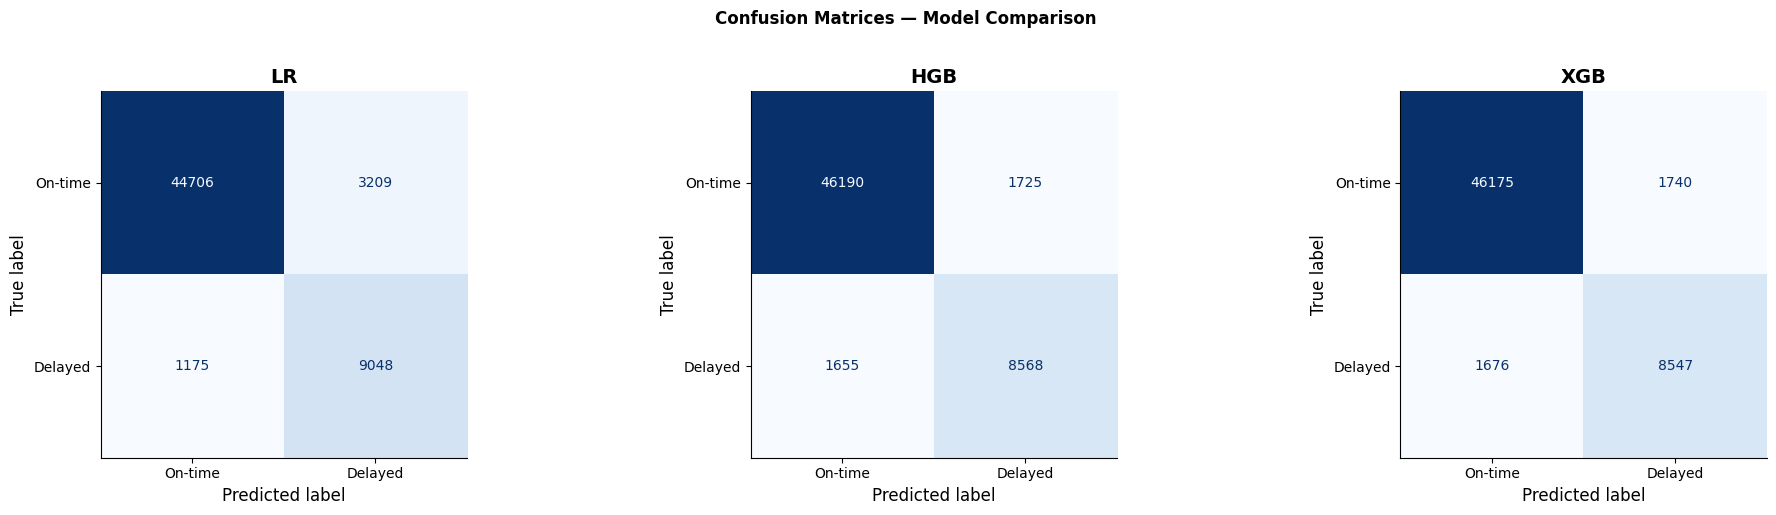

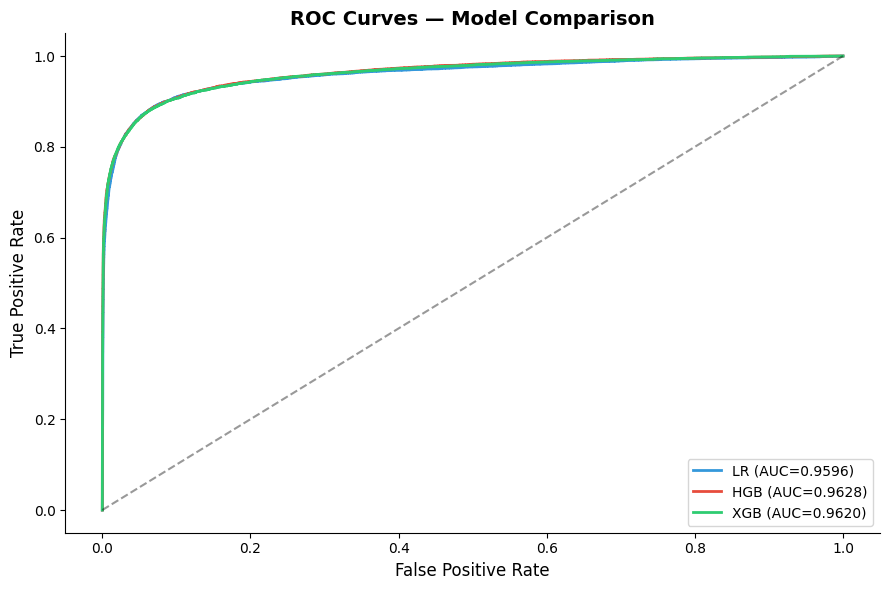

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# ─────────────────────────────────────────────────────────────────────────────
# 1️⃣ Extract models + predictions
# ─────────────────────────────────────────────────────────────────────────────
models = {
    'LR': results_clf['LR'][1],
    'HGB': results_clf['HGB'][1],
    'XGB': results_clf['XGB'][1]
}

y_pred = {}
y_prob = {}

for name, model in models.items():
    y_pred[name] = model.predict(X_test)
    y_prob[name] = model.predict_proba(X_test)[:, 1]


# ─────────────────────────────────────────────────────────────────────────────
# 2️⃣ Classification results table (CV scores)
# ─────────────────────────────────────────────────────────────────────────────
clf_df = pd.DataFrame({
    name: {'CV_F1': results_clf[name][0]}
    for name in results_clf
}).T.round(4)

print('─── Classification Results (Cross-Validation F1) ───────────────────────')
display(clf_df.style.highlight_max(axis=0, color='#d4edda'))


# ─────────────────────────────────────────────────────────────────────────────
# 3️⃣ Confusion Matrices
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, name in zip(axes, ['LR', 'HGB', 'XGB']):
    cm = confusion_matrix(y_clf_test, y_pred[name])

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['On-time', 'Delayed']
    ).plot(ax=ax, cmap='Blues', colorbar=False)

    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Model Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# 4️⃣ ROC Curves
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    'LR': '#3498db',
    'HGB': '#e74c3c',
    'XGB': '#2ecc71'
}

for name in ['LR', 'HGB', 'XGB']:
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob[name])
    auc = roc_auc_score(y_clf_test, y_prob[name])

    ax.plot(
        fpr, tpr,
        linewidth=2,
        color=colors[name],
        label=f'{name} (AUC={auc:.4f})'
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()


# # ─────────────────────────────────────────────────────────────────────────────
# # 5️⃣ Feature Importance (HGB)
# # ─────────────────────────────────────────────────────────────────────────────
# hgb_model = models['HGB'].named_steps['model']

# fi_hgb = pd.Series(
#     hgb_model.feature_importances_,
#     index=CLF_COLS[:len(hgb_model.feature_importances_)]
# ).sort_values(ascending=False)

# fig, ax = plt.subplots(figsize=(14, 5))

# fi_hgb.head(15).plot(
#     kind='bar',
#     ax=ax,
#     color=sns.color_palette('viridis', 15)
# )

# ax.set_title('Feature Importance — HistGradientBoosting', fontweight='bold')
# ax.set_ylabel('Importance')
# ax.tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

─── Regression Results (Sklearn — sample) ────────────────────────────────


,R²
LR,0.922
HGB,0.911
XGB,0.919


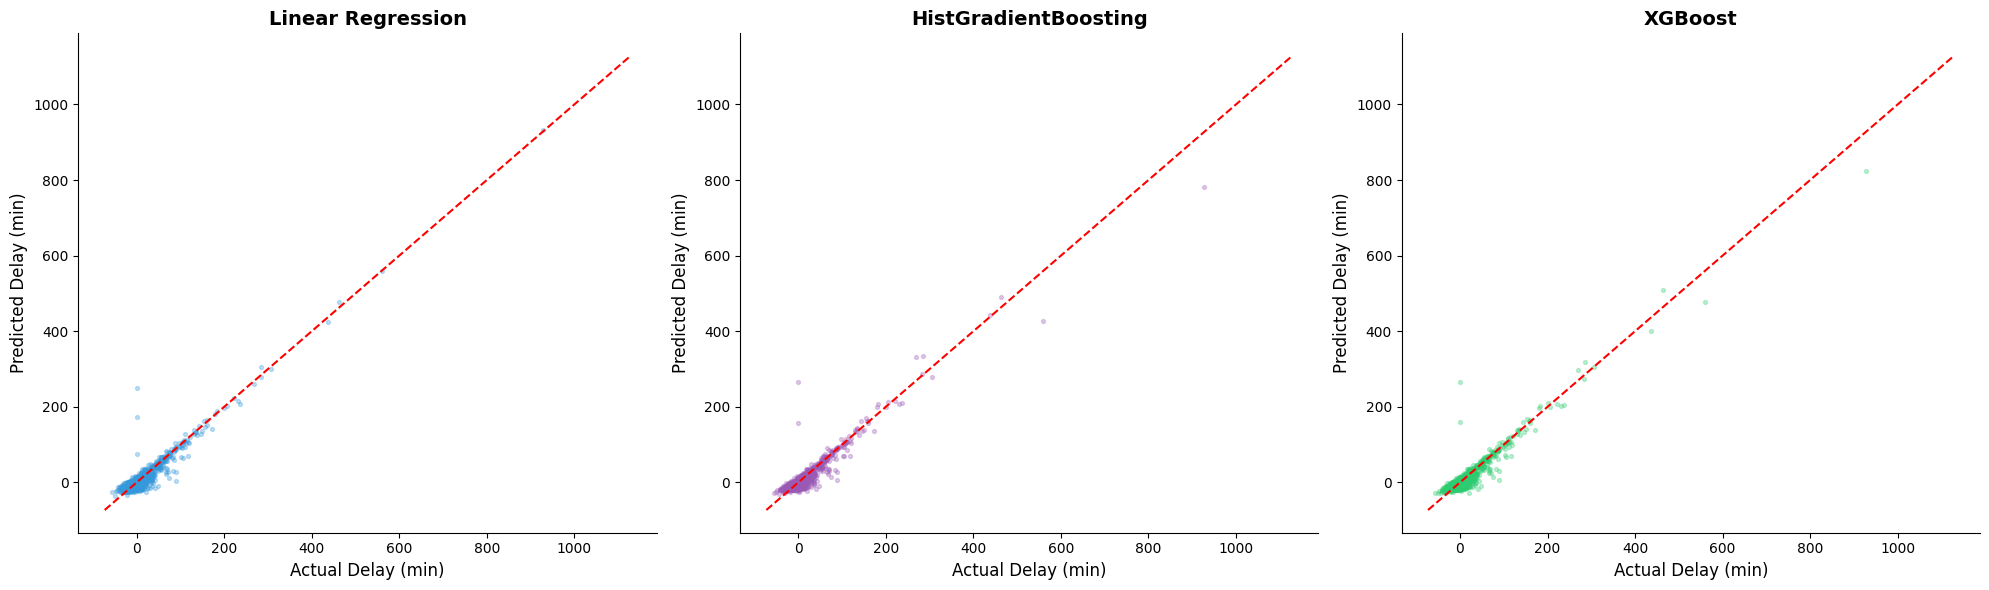

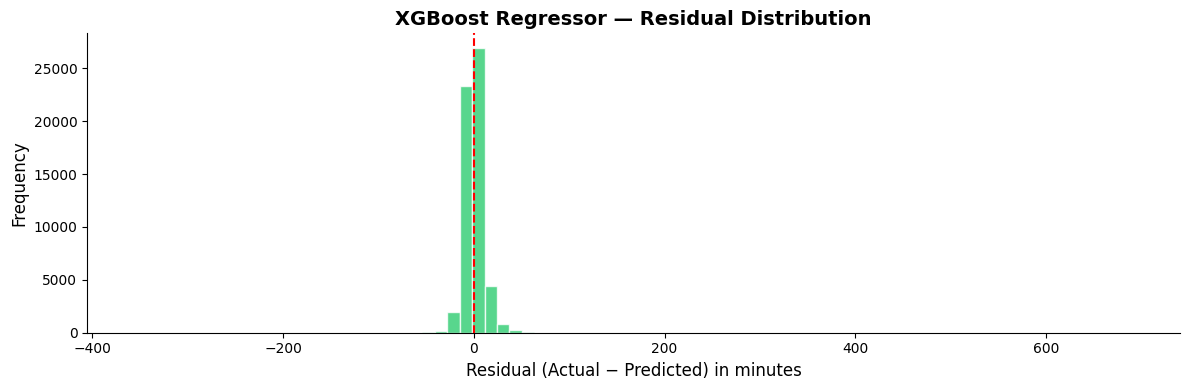

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score

# ─────────────────────────────────────────────────────────────────────────────
# 1️⃣ Extract predictions from stored pipelines
# ─────────────────────────────────────────────────────────────────────────────
y_pred_lr_reg  = results_reg['LR'][1].predict(X_reg_test)
y_pred_hgb_reg = results_reg['HGB'][1].predict(X_reg_test)
y_pred_xgb_reg = results_reg['XGB'][1].predict(X_reg_test)

# ─────────────────────────────────────────────────────────────────────────────
# 2️⃣ Results table
# ─────────────────────────────────────────────────────────────────────────────
reg_df = pd.DataFrame({
    'LR':  results_reg['LR'][0],
    'HGB': results_reg['HGB'][0],
    'XGB': results_reg['XGB'][0],
}, index=['R²'])

print('─── Regression Results (Sklearn — sample) ────────────────────────────────')
display(reg_df.T.style.format('{:.3f}'))

# ─────────────────────────────────────────────────────────────────────────────
# 3️⃣ Actual vs Predicted scatter
# ─────────────────────────────────────────────────────────────────────────────
sample_n = min(2000, len(y_reg_test))
idx_s = np.random.choice(len(y_reg_test), sample_n, replace=False)

all_preds = np.concatenate([y_pred_lr_reg, y_pred_hgb_reg, y_pred_xgb_reg])
lim_lo = float(min(y_reg_test.min(), all_preds.min()))
lim_hi = float(max(y_reg_test.max(), all_preds.max()))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    (axes[0], y_pred_lr_reg,  '#3498db', 'Linear Regression'),
    (axes[1], y_pred_hgb_reg, '#9b59b6', 'HistGradientBoosting'),
    (axes[2], y_pred_xgb_reg, '#2ecc71', 'XGBoost')
]

for ax, y_p, color, title in models:
    ax.scatter(
        y_reg_test.values[idx_s],
        y_p[idx_s],
        alpha=0.3,
        s=8,
        color=color
    )

    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            'r--', linewidth=1.5)

    ax.set_xlabel('Actual Delay (min)')
    ax.set_ylabel('Predicted Delay (min)')
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4️⃣ Residual plot (best model: XGB)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

residuals = y_reg_test.values - y_pred_xgb_reg

ax.hist(residuals, bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--')

ax.set_title('XGBoost Regressor — Residual Distribution', fontweight='bold')
ax.set_xlabel('Residual (Actual − Predicted) in minutes')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 9.8 Hyperparameter Tuning — HistGradientBoosting (Pandas)

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import precision_recall_curve

# param_dist = {
#     'max_iter'        : [200, 300, 400],
#     'max_depth'       : [5, 6, 8, 10],
#     'learning_rate'   : [0.02, 0.03, 0.05, 0.08],
#     'min_samples_leaf': [10, 20, 30],
# }
# sub_n  = min(50_000, len(X_train_bal))
# sub_idx = np.random.choice(len(X_train_bal), sub_n, replace=False)
# X_sub = X_train_bal.iloc[sub_idx] if hasattr(X_train_bal,'iloc') else X_train_bal[sub_idx]
# y_sub = y_clf_train_bal.iloc[sub_idx] if hasattr(y_clf_train_bal,'iloc') else y_clf_train_bal[sub_idx]

# rs = RandomizedSearchCV(
#     HistGradientBoostingClassifier(random_state=RANDOM_SEED),
#     param_dist, n_iter=20, cv=3, scoring='f1',
#     n_jobs=-1, random_state=RANDOM_SEED, verbose=0
# )
# rs.fit(X_sub, y_sub)
# print(f'Best params : {rs.best_params_}')
# print(f'Best CV F1  : {rs.best_score_:.4f}')

# best_hgb = rs.best_estimator_
# best_hgb.fit(X_train_bal, y_clf_train_bal)
# y_pred_best = best_hgb.predict(X_test)
# y_prob_best = best_hgb.predict_proba(X_test)[:, 1]

# # ── Threshold optimisation ────────────────────────────────────────────────────
# prec_t, rec_t, thresh_t = precision_recall_curve(y_clf_test, y_prob_best)
# f1_t = 2 * prec_t * rec_t / (prec_t + rec_t + 1e-9)
# best_thresh = thresh_t[f1_t[:-1].argmax()]
# y_pred_opt  = (y_prob_best >= best_thresh).astype(int)

# tuned_res = eval_classifier('HGB Tuned (optimal threshold)', y_clf_test, y_pred_opt, y_prob_best)
# clf_results.append(tuned_res)
# print(f'\nOptimal threshold : {best_thresh:.3f}')
# print(f'F1 @ default 0.5  : {f1_score(y_clf_test, y_pred_best):.4f}')
# print(f'F1 @ optimal      : {f1_score(y_clf_test, y_pred_opt):.4f}')

# fig, ax = plt.subplots(figsize=(11, 4))
# ax.plot(thresh_t, prec_t[:-1], '#3498db', linewidth=1.8, label='Precision')
# ax.plot(thresh_t, rec_t[:-1],  '#e74c3c', linewidth=1.8, label='Recall')
# ax.plot(thresh_t, f1_t[:-1],   '#2ecc71', linewidth=2.2, label='F1')
# ax.axvline(best_thresh, color='black', linestyle='--', linewidth=1.5,
#            label=f'Optimal ({best_thresh:.3f})')
# ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
# ax.set_title('Threshold Optimisation — Precision / Recall / F1', fontweight='bold')
# ax.legend(); ax.set_xlim(0.1, 0.9)
# plt.tight_layout(); plt.show()

### 9.9 Scalability Comparison — Pandas vs Spark

In [ ]:
# def _get_metric(res_list, name, metric):
#     for r in res_list:
#         if r['Model'] == name:
#             return r[metric]
#     return 0.0

# scalability_data = {
#     'Model'   : ['Sklearn LR (5% sample)','Sklearn HGB (5% sample)','Sklearn GB (5% sample)',
#                  'Spark GBT (100% full)'],
#     'Framework': ['Scikit-learn','Scikit-learn','Scikit-learn','PySpark MLlib'],
#     'Training Rows': [int(len(X_train_bal))] * 3 + [int(sdf_train.count())],
#     'AUC-ROC' : [
#         _get_metric(clf_results,'Logistic Regression (baseline)','ROC-AUC'),
#         _get_metric(clf_results,'HistGradientBoosting','ROC-AUC'),
#         _get_metric(clf_results,'GradientBoosting','ROC-AUC'),
#         spark_gbt_auc
#     ],
#     'F1-Score': [
#         _get_metric(clf_results,'Logistic Regression (baseline)','F1'),
#         _get_metric(clf_results,'HistGradientBoosting','F1'),
#         _get_metric(clf_results,'GradientBoosting','F1'),
#         spark_gbt_f1
#     ]
# }
# scale_df = pd.DataFrame(scalability_data)
# print('Scalability & Performance Comparison')
# display(scale_df.round(4))

# colors = ['#3498db' if f=='Scikit-learn' else '#e74c3c' for f in scale_df['Framework']]
# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# scale_df.set_index('Model')['AUC-ROC'].plot(kind='bar', ax=axes[0], color=colors, alpha=0.85)
# axes[0].set_title('AUC-ROC: Sklearn (5%) vs Spark (100%)', fontweight='bold')
# axes[0].axhline(0.5, color='grey', linestyle='--', alpha=0.5)
# axes[0].tick_params(axis='x', rotation=30)

# scale_df.set_index('Model')['Training Rows'].plot(kind='bar', ax=axes[1], color=colors, alpha=0.85)
# axes[1].set_title('Scale: Training Rows Processed', fontweight='bold')
# axes[1].tick_params(axis='x', rotation=30)
# for i_b, (_, row) in enumerate(scale_df.iterrows()):
#     axes[1].text(i_b, row['Training Rows']*1.02, f"{int(row['Training Rows']):,}",
#                  ha='center', fontsize=8, fontweight='bold')

# from matplotlib.patches import Patch
# axes[1].legend(handles=[
#     Patch(facecolor='#3498db', label='Scikit-learn (5% sample)'),
#     Patch(facecolor='#e74c3c', label='PySpark MLlib (100%)')
# ])
# plt.tight_layout(); plt.show()

---
## 10. 📈 Descriptive Analytics — Pattern Discovery

### 10.1 FP-Growth — Frequent Delay Pattern Mining

In [ ]:
# ── FP-Growth: build transactions from SAMPLE (pandas) ───────────────────────
# Each delayed flight becomes a "basket" of categorical items derived from
# pre-takeoff columns only. No post-departure information is included.

delayed_flights = pdf_model[pdf_model['IS_DELAYED'] == 1].copy()

if 'DEP_HOUR' not in delayed_flights.columns:
    delayed_flights['DEP_HOUR'] = (
        delayed_flights['SCHEDULED_DEPARTURE'] // 100
    ).clip(0, 23).astype(int)

if 'IS_WEEKEND' not in delayed_flights.columns:
    delayed_flights['IS_WEEKEND'] = delayed_flights['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Item-bucket helpers ───────────────────────────────────────────────────────
def hour_bucket(h):
    h = int(h)
    if h < 6:   return 'Night(00-05)'
    if h < 12:  return 'Morning(06-11)'
    if h < 17:  return 'Afternoon(12-16)'
    if h < 21:  return 'Evening(17-20)'
    return 'Night(21-23)'

def dep_delay_bucket(d):
    d = float(d)
    if d <= 0:   return 'OnTime'
    if d <= 15:  return 'MinorDelay(1-15min)'
    if d <= 60:  return 'Delayed(16-60min)'
    return 'SevereDelay(>60min)'

def dist_bucket(d):
    d = float(d)
    if d < 500:   return 'Short(<500mi)'
    if d < 1500:  return 'Medium(500-1500mi)'
    return 'Long(>1500mi)'

def build_transaction(row):
    items = [
        hour_bucket(row.get('DEP_HOUR', 12)),
        dep_delay_bucket(row.get('DEPARTURE_DELAY', 0)),
        dist_bucket(row.get('DISTANCE', 500)),
        'Weekend' if int(row.get('IS_WEEKEND', 0)) == 1 else 'Weekday',
        f"Month{int(row.get('MONTH', 1))}",
    ]
    if 'AIRLINE' in row.index and pd.notna(row['AIRLINE']):
        items.append(f"Airline:{str(row['AIRLINE'])}")
    return [it for it in items if it]

transactions = delayed_flights.apply(build_transaction, axis=1).tolist()

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'[SAMPLE] FP-Growth transactions : {len(basket_df):,} delayed flights')
print(f'  Unique items : {list(te.columns_)}')


[SAMPLE] FP-Growth transactions : 51,116 delayed flights
  Unique items : ['Afternoon(12-16)', 'Delayed(16-60min)', 'Evening(17-20)', 'Long(>1500mi)', 'Medium(500-1500mi)', 'MinorDelay(1-15min)', 'Month1', 'Month10', 'Month11', 'Month12', 'Month2', 'Month3', 'Month4', 'Month5', 'Month6', 'Month7', 'Month8', 'Month9', 'Morning(06-11)', 'Night(00-05)', 'Night(21-23)', 'OnTime', 'SevereDelay(>60min)', 'Short(<500mi)', 'Weekday', 'Weekend']


[SAMPLE] Frequent itemsets : 99
[SAMPLE] Association rules : 168

Top 10 Frequent Delay Patterns (sample):


,itemsets,support
0,Weekday,0.7587
6,Medium(500-1500mi),0.5103
7,Delayed(16-60min),0.4735
43,"Medium(500-1500mi), Weekday",0.3856
44,"Delayed(16-60min), Weekday",0.3593
1,Short(<500mi),0.3554
10,Afternoon(12-16),0.3279
11,Evening(17-20),0.3114
9,SevereDelay(>60min),0.3112
25,"Short(<500mi), Weekday",0.2744



Top 10 Association Rules by Lift (sample):


,antecedents,consequents,support,confidence,lift
154,"Medium(500-1500mi), SevereDelay(>60min)",Evening(17-20),0.0579,0.3568,1.1459
159,Evening(17-20),"Medium(500-1500mi), SevereDelay(>60min)",0.0579,0.1860,1.1459
156,"Evening(17-20), Medium(500-1500mi)",SevereDelay(>60min),0.0579,0.3532,1.1350
157,SevereDelay(>60min),"Evening(17-20), Medium(500-1500mi)",0.0579,0.1861,1.1350
128,Delayed(16-60min),"Afternoon(12-16), Short(<500mi)",0.0613,0.1295,1.1080
125,"Afternoon(12-16), Short(<500mi)",Delayed(16-60min),0.0613,0.5246,1.1080
151,Delayed(16-60min),"Evening(17-20), Short(<500mi)",0.0593,0.1253,1.0956
150,"Evening(17-20), Short(<500mi)",Delayed(16-60min),0.0593,0.5187,1.0956
27,Short(<500mi),"Delayed(16-60min), Weekday",0.1391,0.3913,1.0892
22,"Delayed(16-60min), Weekday",Short(<500mi),0.1391,0.3871,1.0892


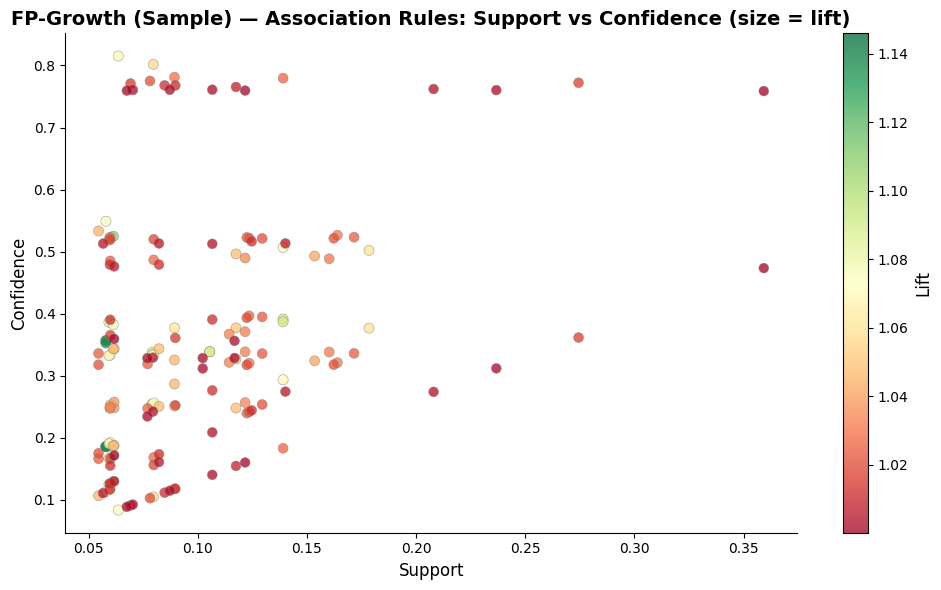

In [ ]:
# ── Run FP-Growth (sample) ────────────────────────────────────────────────────
freq_items = fpgrowth(basket_df, min_support=0.05, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)

rules = association_rules(freq_items, metric='lift', min_threshold=1.0,
                          num_itemsets=len(freq_items))
rules = rules.sort_values('lift', ascending=False)

print(f'[SAMPLE] Frequent itemsets : {len(freq_items)}')
print(f'[SAMPLE] Association rules : {len(rules)}')

print('\nTop 10 Frequent Delay Patterns (sample):')
display(
    freq_items.head(10)
    .assign(itemsets=freq_items.head(10)['itemsets'].apply(lambda x: ', '.join(sorted(x))))
    [['itemsets', 'support']].round(4)
)

print('\nTop 10 Association Rules by Lift (sample):')
rules_display = rules.head(10).copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(sorted(x)))
display(rules_display[['antecedents','consequents','support','confidence','lift']].round(4))

# Support vs Confidence bubble chart
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.75,
    s=rules['lift'] * 50, edgecolors='grey', linewidth=0.4
)
plt.colorbar(sc, ax=ax, label='Lift')
ax.set_xlabel('Support');  ax.set_ylabel('Confidence')
ax.set_title('FP-Growth (Sample) — Association Rules: Support vs Confidence (size = lift)',
             fontweight='bold')
plt.tight_layout(); plt.show()


[FULL DATASET] FP-Growth transactions : 1,023,498 delayed flights
Training Spark FPGrowth on full dataset...
  Done in 30.7s

[FULL DATASET] Top 15 Frequent Itemsets:


,itemsets,freq
0,Weekday,775967
1,Medium(500-1500mi),522803
2,Delayed(16-60min),482931
3,"Medium(500-1500mi), Weekday",394731
4,"Delayed(16-60min), Weekday",365216
5,Short(<500mi),363460
6,Afternoon(12-16),337155
7,SevereDelay(>60min),320732
8,Evening(17-20),319930
9,"Short(<500mi), Weekday",280071



[FULL DATASET] Top 10 Association Rules by Lift:


,antecedent,consequent,confidence,lift
0,Airline:EV,Short(<500mi),0.5784,1.6288
1,Airline:OO,Short(<500mi),0.5574,1.5698
2,"Delayed(16-60min), Short(<500mi)",Airline:WN,0.3157,1.4214
3,"Airline:WN, Short(<500mi)",Delayed(16-60min),0.6178,1.3093
4,"Airline:WN, Delayed(16-60min)",Short(<500mi),0.4384,1.2344
5,"Airline:WN, Weekday",Delayed(16-60min),0.5808,1.2308
6,Airline:WN,Delayed(16-60min),0.5780,1.2250
7,"Airline:AA, Weekday",Medium(500-1500mi),0.6237,1.2211
8,Airline:AA,Medium(500-1500mi),0.6237,1.2211
9,"Airline:WN, Medium(500-1500mi)",Delayed(16-60min),0.5575,1.1816


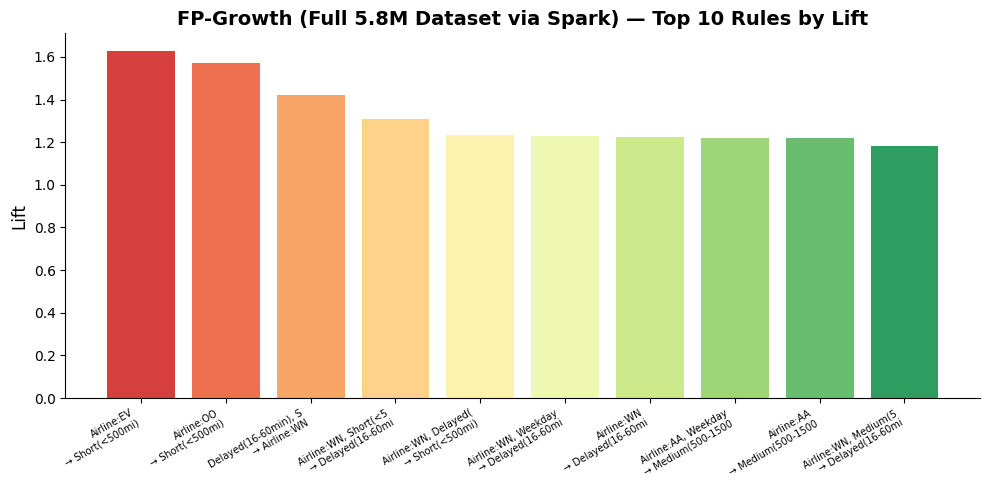

In [ ]:
# ── FP-Growth — FULL DATASET via PySpark FPGrowth ────────────────────────────
# PySpark FPGrowth works natively on Spark DataFrames.
# We bucket the same pre-takeoff features on sdf_clean and run distributed FP-Growth.

from pyspark.ml.fpm import FPGrowth as SparkFPGrowth

# ── Build item-string columns on sdf_clean ────────────────────────────────────
sdf_fp = sdf_clean

sdf_fp = sdf_fp.withColumn('DEP_HOUR_FP',
    (F.col('SCHEDULED_DEPARTURE') / 100).cast('int').cast('double'))

sdf_fp = sdf_fp.withColumn('HOUR_ITEM',
    F.when(F.col('DEP_HOUR_FP') < 6,  'Night(00-05)')
     .when(F.col('DEP_HOUR_FP') < 12, 'Morning(06-11)')
     .when(F.col('DEP_HOUR_FP') < 17, 'Afternoon(12-16)')
     .when(F.col('DEP_HOUR_FP') < 21, 'Evening(17-20)')
     .otherwise('Night(21-23)')
)

sdf_fp = sdf_fp.withColumn('DELAY_ITEM',
    F.when(F.col('DEPARTURE_DELAY') <= 0,   'OnTime')
     .when(F.col('DEPARTURE_DELAY') <= 15,  'MinorDelay(1-15min)')
     .when(F.col('DEPARTURE_DELAY') <= 60,  'Delayed(16-60min)')
     .otherwise('SevereDelay(>60min)')
)

sdf_fp = sdf_fp.withColumn('DIST_ITEM',
    F.when(F.col('DISTANCE') < 500,  'Short(<500mi)')
     .when(F.col('DISTANCE') < 1500, 'Medium(500-1500mi)')
     .otherwise('Long(>1500mi)')
)

sdf_fp = sdf_fp.withColumn('DAY_ITEM',
    F.when(F.col('DAY_OF_WEEK').isin([6, 7]), 'Weekend')
     .otherwise('Weekday')
)

sdf_fp = sdf_fp.withColumn('MONTH_ITEM',
    F.concat(F.lit('Month'), F.col('MONTH').cast('string'))
)

sdf_fp = sdf_fp.withColumn('AIRLINE_ITEM',
    F.concat(F.lit('Airline:'), F.col('AIRLINE').cast('string'))
)

# ── Filter to delayed flights only & build items array ───────────────────────
sdf_fp_delayed = sdf_fp.filter(F.col('ARRIVAL_DELAY') > 15)

sdf_fp_txn = sdf_fp_delayed.select(
    F.array(
        'HOUR_ITEM', 'DELAY_ITEM', 'DIST_ITEM',
        'DAY_ITEM', 'MONTH_ITEM', 'AIRLINE_ITEM'
    ).alias('items')
).filter(F.col('items').isNotNull())

n_delayed_full = sdf_fp_txn.count()
print(f'[FULL DATASET] FP-Growth transactions : {n_delayed_full:,} delayed flights')

# ── Run Spark FP-Growth ───────────────────────────────────────────────────────
fp_model = SparkFPGrowth(
    itemsCol='items',
    minSupport=0.05,
    minConfidence=0.3
)

print('Training Spark FPGrowth on full dataset...')
t0 = time.time()
fp_fit = fp_model.fit(sdf_fp_txn)
print(f'  Done in {time.time()-t0:.1f}s')

# Frequent itemsets
spark_freq_items = fp_fit.freqItemsets.orderBy('freq', ascending=False)
spark_freq_pd = spark_freq_items.limit(20).toPandas()
spark_freq_pd['itemsets'] = spark_freq_pd['items'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n[FULL DATASET] Top 15 Frequent Itemsets:')
display(spark_freq_pd[['itemsets','freq']].head(15))

# Association rules
spark_rules_pd = fp_fit.associationRules.orderBy('lift', ascending=False).limit(20).toPandas()
spark_rules_pd['antecedent'] = spark_rules_pd['antecedent'].apply(lambda x: ', '.join(sorted(x)))
spark_rules_pd['consequent'] = spark_rules_pd['consequent'].apply(lambda x: ', '.join(sorted(x)))

print(f'\n[FULL DATASET] Top 10 Association Rules by Lift:')
display(spark_rules_pd[['antecedent','consequent','confidence','lift']].head(10).round(4))

# Visualise lift distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(spark_rules_pd.head(10))),
       spark_rules_pd.head(10)['lift'],
       color=sns.color_palette('RdYlGn', 10), alpha=0.9)
ax.set_xticks(range(len(spark_rules_pd.head(10))))
ax.set_xticklabels(
    [f"{r['antecedent'][:20]}\n→ {r['consequent'][:15]}"
     for _, r in spark_rules_pd.head(10).iterrows()],
    fontsize=7, rotation=30, ha='right'
)
ax.set_ylabel('Lift')
ax.set_title('FP-Growth (Full 5.8M Dataset via Spark) — Top 10 Rules by Lift',
             fontweight='bold')
plt.tight_layout(); plt.show()


### 10.1B FP-Growth — Actionable Business Rule Interpretation

In [ ]:
# ── Actionable rule interpretation — SAMPLE ───────────────────────────────────
strong_rules = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift']       >= 1.1) &
    (rules['support']    >= 0.05)
].copy()
if len(strong_rules) == 0:
    strong_rules = rules.sort_values('lift', ascending=False).head(8).copy()

strong_rules['antecedents_str'] = strong_rules['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
strong_rules['consequents_str'] = strong_rules['consequents'].apply(lambda x: ' + '.join(sorted(x)))

def interpret_rule(ant):
    a = ant.lower()
    if 'evening' in a or 'night(21' in a:
        return 'Evening/night departures cascade into late-aircraft delays'
    if 'severe' in a or 'delayed(16' in a:
        return 'Significant gate delay almost always propagates to arrival delay'
    if 'morning' in a:
        return 'Morning slot — airline readiness (crew, aircraft positioning) is key driver'
    if 'weekend' in a:
        return 'Weekend flights show different delay patterns vs weekday congestion'
    if 'long' in a:
        return 'Long-haul routes have lower delay rates — more buffer time built into schedule'
    if 'short' in a:
        return 'Short-haul routes amplify delay propagation — less recovery buffer'
    return 'These pre-takeoff factors co-occur more than expected by chance'

print('━━━ Actionable Rules from Sample FP-Growth ━━━━━━━━━━━━━━━━━━━━━━━━━━━')
for i, (_, row) in enumerate(strong_rules.head(8).iterrows()):
    print(f'  Rule {i+1}: IF [{row["antecedents_str"]}]  →  [{row["consequents_str"]}]')
    print(f'    Support={row["support"]:.3f} | Confidence={row["confidence"]:.3f} | Lift={row["lift"]:.3f}')
    print(f'    Insight: {interpret_rule(row["antecedents_str"])}')
    print()

# ── Actionable rule interpretation — FULL DATASET ─────────────────────────────
print('━━━ Actionable Rules from Full Dataset (Spark FP-Growth) ━━━━━━━━━━━━━')
for i, (_, row) in enumerate(spark_rules_pd.head(8).iterrows()):
    print(f'  Rule {i+1}: IF [{row["antecedent"]}]  →  [{row["consequent"]}]')
    print(f'    Confidence={row["confidence"]:.3f} | Lift={row["lift"]:.3f}')
    print(f'    Insight: {interpret_rule(row["antecedent"])}')
    print()

print('━━━ Key Business Implications ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print('  1. Early-morning slots (06-11) show lowest cascade risk — book these')
print('  2. SevereDelay(>60min) is a near-certain predictor of arrival delay')
print('  3. Evening departures at major hubs need pre-positioned spare aircraft')
print('  4. Short-haul weekend flights: highest substitution risk (cancel vs delay)')
print('  5. Full-dataset rules confirm sample patterns — sample is representative')

print()
print('━━━ Sample vs Full Dataset Comparison ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'  Sample transactions  : {len(basket_df):,}   (pandas, 5% of data)')
print(f'  Full  transactions   : {n_delayed_full:,}  (Spark, 100% of data)')
print(f'  Sample top-1 rule lift : {rules.iloc[0]["lift"]:.3f}')
print(f'  Full  top-1 rule lift  : {spark_rules_pd.iloc[0]["lift"]:.3f}')


━━━ Actionable Rules from Sample FP-Growth ━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Rule 1: IF [Afternoon(12-16) + Short(<500mi)]  →  [Delayed(16-60min)]
    Support=0.061 | Confidence=0.525 | Lift=1.108
    Insight: Short-haul routes amplify delay propagation — less recovery buffer

━━━ Actionable Rules from Full Dataset (Spark FP-Growth) ━━━━━━━━━━━━━
  Rule 1: IF [Airline:EV]  →  [Short(<500mi)]
    Confidence=0.578 | Lift=1.629
    Insight: These pre-takeoff factors co-occur more than expected by chance

  Rule 2: IF [Airline:OO]  →  [Short(<500mi)]
    Confidence=0.557 | Lift=1.570
    Insight: These pre-takeoff factors co-occur more than expected by chance

  Rule 3: IF [Delayed(16-60min), Short(<500mi)]  →  [Airline:WN]
    Confidence=0.316 | Lift=1.421
    Insight: Significant gate delay almost always propagates to arrival delay

  Rule 4: IF [Airline:WN, Short(<500mi)]  →  [Delayed(16-60min)]
    Confidence=0.618 | Lift=1.309
    Insight: Short-haul routes amplify delay propagation — les

### 10.2 K-Means Clustering — Airport Segmentation

In [ ]:
pdf_model.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME',
       'DEPARTURE_DELAY', 'TAXI_OUT', 'SCHEDULED_TIME', 'DISTANCE',
       'SCHEDULED_ARRIVAL', 'ARRIVAL_DELAY', 'IS_DELAYED', 'DELAY_DURATION'],
      dtype='object')

In [ ]:
pdf_clean.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
       'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON',
       'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
       'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY',
       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
       'WEATHER_DELAY', 'ROUTE', 'DIST_QUARTILE', 'DEP_HOUR', 'HOUR_BUCKET',
       'DELAY_SEVERITY'],
      dtype='object')

In [ ]:
pdf_model['ORIGIN_AIRPORT'] = pdf_clean['ORIGIN_AIRPORT']

In [ ]:
pdf_model['CANCELLED'] = pdf_clean['CANCELLED']

In [ ]:
pdf_clean

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,...,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ROUTE,DIST_QUARTILE,DEP_HOUR,HOUR_BUCKET,DELAY_SEVERITY
0,1,1,4,DL,1560,ANC,SEA,45,31.0,-14.0,...,0.0,0.0,0.0,0.0,0.0,ANC→SEA,Very Long\n(>1200mi),0,Night\n0-6,0. On-time (<15)
1,1,1,4,OO,7370,BJI,MSP,520,517.0,-3.0,...,0.0,0.0,0.0,0.0,0.0,BJI→MSP,Short\n(<400mi),5,Night\n0-6,0. On-time (<15)
2,1,1,4,OO,5460,RDD,SFO,530,NaN,0.0,...,0.0,0.0,0.0,0.0,0.0,RDD→SFO,Short\n(<400mi),5,Night\n0-6,0. On-time (<15)
3,1,1,4,B6,1012,ORD,BOS,540,529.0,-11.0,...,0.0,0.0,0.0,0.0,0.0,ORD→BOS,Long\n(700-1200mi),5,Night\n0-6,0. On-time (<15)
4,1,1,4,EV,3268,ATL,IAD,540,556.0,16.0,...,0.0,0.0,0.0,0.0,0.0,ATL→IAD,Medium\n(400-700mi),5,Night\n0-6,0. On-time (<15)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290681,12,31,4,NK,806,LAS,ATL,2335,2400.0,25.0,...,0.0,0.0,0.0,0.0,0.0,LAS→ATL,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290682,12,31,4,NK,970,DEN,FLL,2355,2348.0,-7.0,...,0.0,0.0,0.0,0.0,0.0,DEN→FLL,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290683,12,31,4,AS,121,SEA,ANC,2355,2355.0,0.0,...,0.0,0.0,0.0,0.0,0.0,SEA→ANC,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)
290684,12,31,4,F9,710,DEN,RSW,2359,2351.0,-8.0,...,0.0,0.0,0.0,0.0,0.0,DEN→RSW,Very Long\n(>1200mi),23,Late\n22-24,0. On-time (<15)


In [ ]:
pdf_model.isna().mean() * 100

MONTH                  0.000000
DAY                    0.000000
DAY_OF_WEEK            0.000000
SCHEDULED_DEPARTURE    0.000000
DEPARTURE_TIME         1.453114
DEPARTURE_DELAY        0.000000
TAXI_OUT               0.000000
SCHEDULED_TIME         0.000000
DISTANCE               0.000000
SCHEDULED_ARRIVAL      0.000000
ARRIVAL_DELAY          0.000000
IS_DELAYED             0.000000
DELAY_DURATION         0.000000
ORIGIN_AIRPORT         0.000000
CANCELLED              0.000000
dtype: float64

In [ ]:
pdf_model.dropna(inplace=True)
pdf_model.reset_index(drop=True, inplace=True)

In [ ]:
pdf_clean = pdf_sample.copy()

delay_cols = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY','LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
pdf_clean[delay_cols] = pdf_clean[delay_cols].fillna(0)

delay_delay_cols = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY']
pdf_clean[delay_delay_cols] = pdf_clean[delay_delay_cols].fillna(0)

pdf_clean['CANCELLATION_REASON'] = pdf_clean['CANCELLATION_REASON'].fillna('N')
time_cols = ['ELAPSED_TIME', 'AIR_TIME', 'TAXI_OUT', 'TAXI_IN','WHEELS_OFF', 'WHEELS_ON']

for col in time_cols:
    pdf_clean[col] = pdf_clean[col].fillna(0)

sdf_clean = sdf

for col in delay_cols + delay_delay_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

sdf_clean = sdf_clean.fillna({'CANCELLATION_REASON': 'N'})

for col in time_cols:
    sdf_clean = sdf_clean.fillna({col: 0})

In [ ]:
pdf_clean.isna().mean() * 100

YEAR                   0.000000
MONTH                  0.000000
DAY                    0.000000
DAY_OF_WEEK            0.000000
AIRLINE                0.000000
FLIGHT_NUMBER          0.000000
TAIL_NUMBER            0.252506
ORIGIN_AIRPORT         0.000000
DESTINATION_AIRPORT    0.000000
SCHEDULED_DEPARTURE    0.000000
DEPARTURE_TIME         1.453114
DEPARTURE_DELAY        0.000000
TAXI_OUT               0.000000
WHEELS_OFF             0.000000
SCHEDULED_TIME         0.000000
ELAPSED_TIME           0.000000
AIR_TIME               0.000000
DISTANCE               0.000000
WHEELS_ON              0.000000
TAXI_IN                0.000000
SCHEDULED_ARRIVAL      0.000000
ARRIVAL_TIME           1.562511
ARRIVAL_DELAY          0.000000
DIVERTED               0.000000
CANCELLED              0.000000
CANCELLATION_REASON    0.000000
AIR_SYSTEM_DELAY       0.000000
SECURITY_DELAY         0.000000
AIRLINE_DELAY          0.000000
LATE_AIRCRAFT_DELAY    0.000000
WEATHER_DELAY          0.000000
dtype: f

In [ ]:
pdf_clean.dropna(inplace=True)
pdf_clean.reset_index(drop=True, inplace=True)

In [ ]:
pdf_model = pdf_clean.copy()

In [ ]:
pdf_model['IS_DELAYED'] = (pdf_model['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)

[SAMPLE] Airport feature matrix: 370 airports x 10 features
Features: ['total_flights', 'delay_rate', 'mean_delay', 'std_delay', 'cancel_rate', 'mean_dist', 'pct_weekend', 'mean_taxi_out', 'pct_evening_flights', 'dominant_cause_enc']


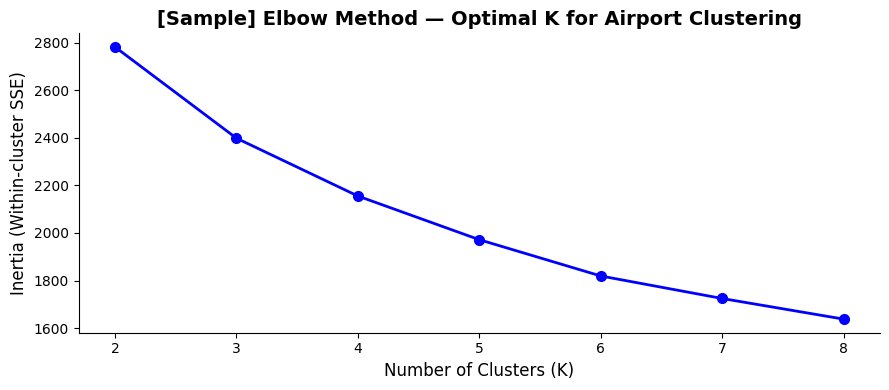

In [ ]:
# ── K-Means Airport Segmentation — SAMPLE (pandas) ───────────────────────────

# ── DEP_HOUR guard ────────────────────────────────────────────────────────────
if 'DEP_HOUR' not in pdf_model.columns:
    pdf_model['DEP_HOUR'] = (pdf_model['SCHEDULED_DEPARTURE'] // 100).clip(0, 23).astype(int)
if 'IS_WEEKEND' not in pdf_model.columns:
    pdf_model['IS_WEEKEND'] = pdf_model['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── Delay cause columns (may be 0-filled) ─────────────────────────────────────
_delay_cause_cols = [c for c in
    ['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']
    if c in pdf_model.columns]

# ── Dominant delay cause per airport (on delayed flights) ────────────────────
if _delay_cause_cols:
    _dom_cause = (
        pdf_model[pdf_model['ARRIVAL_DELAY'] >= DELAY_THRESHOLD]
        .groupby('ORIGIN_AIRPORT')[_delay_cause_cols]
        .mean()
        .idxmax(axis=1)
        .map({'AIR_SYSTEM_DELAY':0,'SECURITY_DELAY':1,
              'AIRLINE_DELAY':2,'LATE_AIRCRAFT_DELAY':3,'WEATHER_DELAY':4})
        .rename('dominant_cause_enc')
    )
else:
    _dom_cause = pd.Series(dtype=float, name='dominant_cause_enc')

# ── Evening flight % ──────────────────────────────────────────────────────────
_evening_pct = (
    pdf_model
    .assign(_is_eve=(pdf_model['DEP_HOUR'] >= 18).astype(int))
    .groupby('ORIGIN_AIRPORT')['_is_eve']
    .mean()
    .rename('pct_evening_flights')
)

# ── Mean taxi-out ─────────────────────────────────────────────────────────────
_taxi_out_mean = (
    pdf_model.groupby('ORIGIN_AIRPORT')['TAXI_OUT']
    .mean()
    .rename('mean_taxi_out')
)

# ── Core airport statistics ───────────────────────────────────────────────────
_agg_dict = {
    'total_flights': ('IS_DELAYED', 'count'),
    'delay_rate'   : ('IS_DELAYED', 'mean'),
    'mean_delay'   : ('ARRIVAL_DELAY', 'mean'),
    'std_delay'    : ('ARRIVAL_DELAY', 'std'),
    'cancel_rate'  : ('CANCELLED', 'mean'),
    'mean_dist'    : ('DISTANCE', 'mean'),
}
if 'IS_WEEKEND' in pdf_model.columns:
    _agg_dict['pct_weekend'] = ('IS_WEEKEND', 'mean')

airport_cluster_df = (
    pdf_model
    .groupby('ORIGIN_AIRPORT')
    .agg(**_agg_dict)
    .dropna()
    .query('total_flights >= 30')
)

airport_cluster_df = (
    airport_cluster_df
    .join(_taxi_out_mean, how='left')
    .join(_evening_pct,   how='left')
    .join(_dom_cause,     how='left')
)
airport_cluster_df = airport_cluster_df.fillna(airport_cluster_df.mean(numeric_only=True))

print(f'[SAMPLE] Airport feature matrix: {airport_cluster_df.shape[0]} airports '
      f'x {airport_cluster_df.shape[1]} features')
print('Features:', list(airport_cluster_df.columns))

# ── Scale ─────────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_airport = StandardScaler().fit_transform(airport_cluster_df)

# ── Elbow method ──────────────────────────────────────────────────────────────
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    km.fit(X_airport)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), inertias, 'bo-', markersize=7, linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('[Sample] Elbow Method — Optimal K for Airport Clustering', fontweight='bold')
plt.tight_layout(); plt.show()

[SAMPLE] Cluster profiles:


,total_flights,delay_rate,mean_delay,std_delay,cancel_rate,mean_dist,pct_weekend,mean_taxi_out,pct_evening_flights,dominant_cause_enc
CLUSTER,,,,,,,,,,
0,5838.517,0.191,4.376,38.794,0.0,960.930,0.261,18.378,0.243,2.517
1,382.102,0.127,-0.170,28.980,0.0,615.209,0.266,13.198,0.142,2.733
2,291.113,0.196,8.144,49.933,0.0,456.433,0.257,14.055,0.117,2.609
3,233.231,0.141,-0.290,29.577,0.0,619.744,0.257,14.484,0.129,0.000


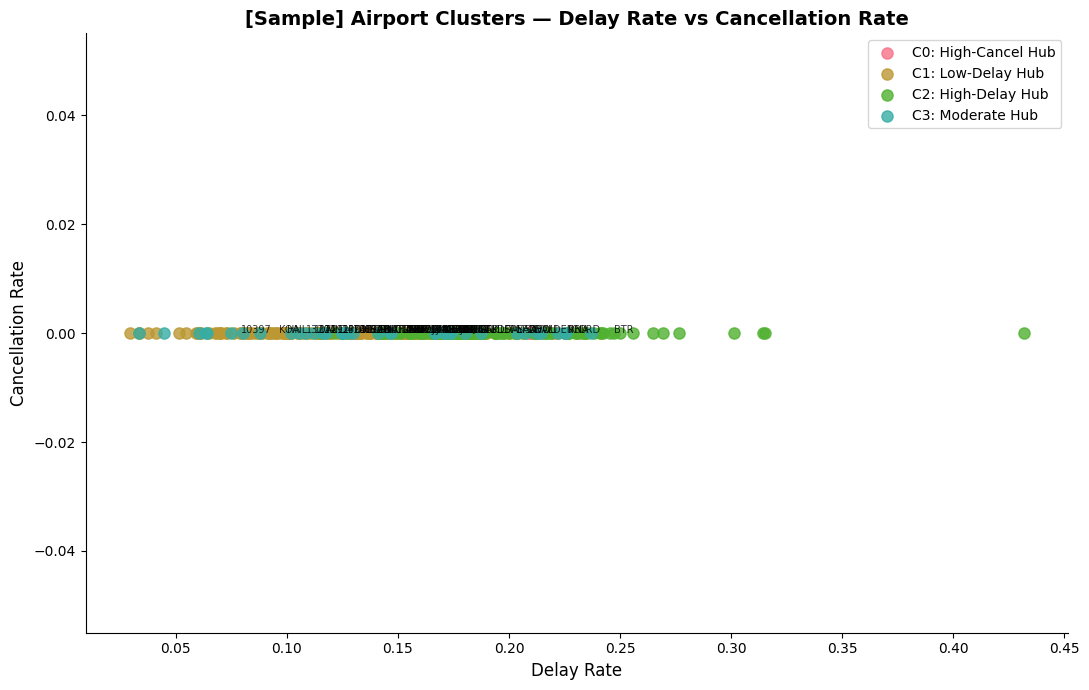


[FULL DATASET] Airport nodes for Spark K-Means: 490


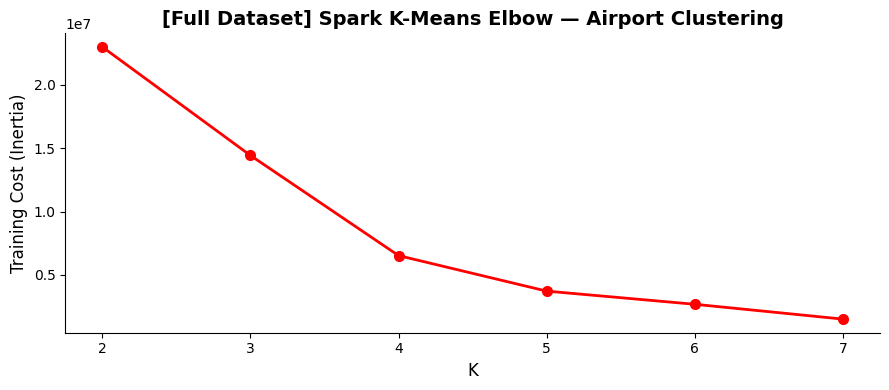


[FULL DATASET] Spark K-Means Cluster Profiles:


,delay_rate,mean_delay,std_delay,cancel_rate,mean_dist,mean_taxi_out,pct_evening_flights,pct_weekend
CLUSTER_SPARK,,,,,,,,
0,0.1425,3.0790,40.9961,0.0233,292.3450,12.9970,0.1118,0.2550
1,0.1551,2.1516,37.8818,0.0097,1099.4895,14.9113,0.1990,0.2828
2,0.1647,4.7964,68.1082,0.0090,3801.0000,12.6497,0.0000,0.2844
3,0.1393,1.9686,38.8095,0.0132,619.6504,13.7353,0.1357,0.2596


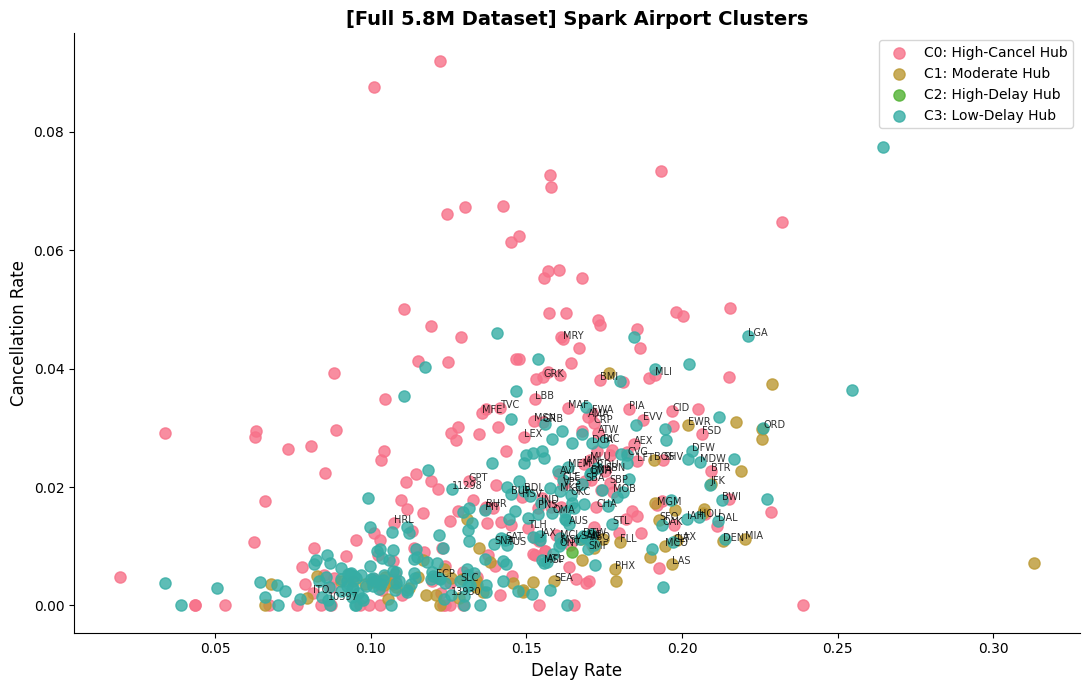

In [ ]:
# ── Fit K-Means K=4 (sample) ──────────────────────────────────────────────────
K_BEST   = 4
km_final = KMeans(n_clusters=K_BEST, random_state=RANDOM_SEED, n_init=10)
airport_cluster_df['CLUSTER'] = km_final.fit_predict(X_airport)

cluster_profiles = airport_cluster_df.groupby('CLUSTER').mean(numeric_only=True).round(3)

# Auto-label clusters
cluster_labels = {}
cluster_labels[cluster_profiles['delay_rate'].idxmin()]  = 'Low-Delay Hub'
cluster_labels[cluster_profiles['delay_rate'].idxmax()]  = 'High-Delay Hub'
cluster_labels[cluster_profiles['cancel_rate'].idxmax()] = 'High-Cancel Hub'
for k in range(K_BEST):
    if k not in cluster_labels:
        cluster_labels[k] = 'Moderate Hub'

airport_cluster_df['CLUSTER_LABEL'] = airport_cluster_df['CLUSTER'].map(cluster_labels)

print('[SAMPLE] Cluster profiles:')
display(cluster_profiles)

# Scatter: delay_rate vs cancel_rate
fig, ax = plt.subplots(figsize=(11, 7))
for cl, grp in airport_cluster_df.groupby('CLUSTER'):
    ax.scatter(grp['delay_rate'], grp['cancel_rate'],
               label=f'C{cl}: {cluster_labels.get(cl,"")}',
               alpha=0.8, s=65)
    for _, row in grp.iterrows():
        if row['total_flights'] > grp['total_flights'].quantile(0.80):
            ax.annotate(row.name, (row['delay_rate'], row['cancel_rate']),
                        fontsize=7, alpha=0.8)
ax.set_xlabel('Delay Rate');  ax.set_ylabel('Cancellation Rate')
ax.set_title('[Sample] Airport Clusters — Delay Rate vs Cancellation Rate', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# ── PySpark K-Means — FULL DATASET ───────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════
from pyspark.ml.clustering import KMeans as SparkKMeans
from pyspark.ml.feature import VectorAssembler as VA

# Aggregate airport statistics on full dataset via Spark SQL
sdf_clean.createOrReplaceTempView('flights_kmeans')

airport_sdf = spark.sql("""
    SELECT
        ORIGIN_AIRPORT,
        COUNT(*)                                           AS total_flights,
        ROUND(AVG(CASE WHEN ARRIVAL_DELAY > 15 THEN 1.0 ELSE 0.0 END), 6) AS delay_rate,
        ROUND(AVG(ARRIVAL_DELAY), 4)                       AS mean_delay,
        ROUND(STDDEV(ARRIVAL_DELAY), 4)                    AS std_delay,
        ROUND(AVG(CANCELLED), 6)                           AS cancel_rate,
        ROUND(AVG(DISTANCE), 2)                            AS mean_dist,
        ROUND(AVG(TAXI_OUT), 4)                            AS mean_taxi_out,
        ROUND(AVG(CASE WHEN (SCHEDULED_DEPARTURE/100) >= 18 THEN 1.0 ELSE 0.0 END), 6)
                                                           AS pct_evening_flights,
        ROUND(AVG(CASE WHEN DAY_OF_WEEK IN (6,7) THEN 1.0 ELSE 0.0 END), 6)
                                                           AS pct_weekend
    FROM flights_kmeans
    WHERE ARRIVAL_DELAY IS NOT NULL
      AND CANCELLED IS NOT NULL
      AND TAXI_OUT IS NOT NULL
      AND DISTANCE IS NOT NULL
    GROUP BY ORIGIN_AIRPORT
    HAVING total_flights >= 200
""")

KMEANS_SPARK_COLS = [
    'delay_rate','mean_delay','std_delay','cancel_rate',
    'mean_dist','mean_taxi_out','pct_evening_flights','pct_weekend'
]

# Cast all to double (required for VectorAssembler)
for c in KMEANS_SPARK_COLS:
    airport_sdf = airport_sdf.withColumn(c, F.col(c).cast('double'))

airport_sdf = airport_sdf.dropna(subset=KMEANS_SPARK_COLS)

va_km = VA(inputCols=KMEANS_SPARK_COLS, outputCol='features', handleInvalid='keep')
airport_vec = va_km.transform(airport_sdf)

n_airports_full = airport_sdf.count()
print(f'\n[FULL DATASET] Airport nodes for Spark K-Means: {n_airports_full:,}')

# Elbow on full data (K=2..7)
spark_inertias = []
for k in range(2, 8):
    km_spark = SparkKMeans(k=k, seed=RANDOM_SEED, maxIter=30, featuresCol='features')
    km_spark_model = km_spark.fit(airport_vec)
    spark_inertias.append(km_spark_model.summary.trainingCost)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(2, 8), spark_inertias, 'ro-', markersize=7, linewidth=2)
ax.set_xlabel('K'); ax.set_ylabel('Training Cost (Inertia)')
ax.set_title('[Full Dataset] Spark K-Means Elbow — Airport Clustering', fontweight='bold')
plt.tight_layout(); plt.show()

# Final K=4
km_spark_final = SparkKMeans(k=4, seed=RANDOM_SEED, maxIter=50, featuresCol='features')
km_spark_model_final = km_spark_final.fit(airport_vec)
airport_clustered_sdf = km_spark_model_final.transform(airport_vec)

# Bring cluster assignments to pandas for profiling
airport_clustered_pd = airport_clustered_sdf.select(
    'ORIGIN_AIRPORT', 'total_flights', 'delay_rate', 'mean_delay',
    'std_delay', 'cancel_rate', 'mean_dist', 'mean_taxi_out',
    'pct_evening_flights', 'pct_weekend', 'prediction'
).toPandas().rename(columns={'prediction': 'CLUSTER_SPARK'})

spark_profiles = airport_clustered_pd.groupby('CLUSTER_SPARK')[
    ['delay_rate','mean_delay','std_delay','cancel_rate','mean_dist',
     'mean_taxi_out','pct_evening_flights','pct_weekend']
].mean().round(4)

spark_labels = {}
spark_labels[spark_profiles['delay_rate'].idxmin()]  = 'Low-Delay Hub'
spark_labels[spark_profiles['delay_rate'].idxmax()]  = 'High-Delay Hub'
spark_labels[spark_profiles['cancel_rate'].idxmax()] = 'High-Cancel Hub'
for k in range(4):
    if k not in spark_labels:
        spark_labels[k] = 'Moderate Hub'

airport_clustered_pd['CLUSTER_LABEL_SPARK'] = airport_clustered_pd['CLUSTER_SPARK'].map(spark_labels)

print('\n[FULL DATASET] Spark K-Means Cluster Profiles:')
display(spark_profiles)

# Scatter
fig, ax = plt.subplots(figsize=(11, 7))
for cl, grp in airport_clustered_pd.groupby('CLUSTER_SPARK'):
    ax.scatter(grp['delay_rate'], grp['cancel_rate'],
               label=f'C{cl}: {spark_labels.get(cl,"")}',
               alpha=0.8, s=65)
    for _, row in grp.iterrows():
        if row['total_flights'] > grp['total_flights'].quantile(0.80):
            ax.annotate(row['ORIGIN_AIRPORT'], (row['delay_rate'], row['cancel_rate']),
                        fontsize=7, alpha=0.8)
ax.set_xlabel('Delay Rate');  ax.set_ylabel('Cancellation Rate')
ax.set_title('[Full 5.8M Dataset] Spark Airport Clusters', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


### 10.2B K-Means — Cluster Profiling, Business Segmentation & Radar Analysis

━━━ SAMPLE (pandas) — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━
  Cluster 0: High-Cancel Hub
    # Airports   : 29
    Delay Rate   : 19.1%
    Mean Delay   : 4.4 min
    Cancel Rate  : 0.0%
    Top airports : ATL, ORD, DFW, DEN, LAX
    Action       : PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.

  Cluster 1: Low-Delay Hub
    # Airports   : 187
    Delay Rate   : 12.7%
    Mean Delay   : -0.2 min
    Cancel Rate  : 0.0%
    Top airports : TPA, PDX, BNA, STL, OAK
    Action       : MONITOR: Average performance. Reduce turnaround time during peak seasons.

  Cluster 2: High-Delay Hub
    # Airports   : 115
    Delay Rate   : 19.6%
    Mean Delay   : 8.1 min
    Cancel Rate  : 0.0%
    Top airports : DAL, HOU, CLE, RDU, CMH
    Action       : PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.

  Cluster 3: Moderate Hub
    # Airports   : 39
    Delay Rate   : 14.1%
    Mean Delay   : -0.3 min
    Cancel Rate  : 0.0%
    Top airports : 13930, C

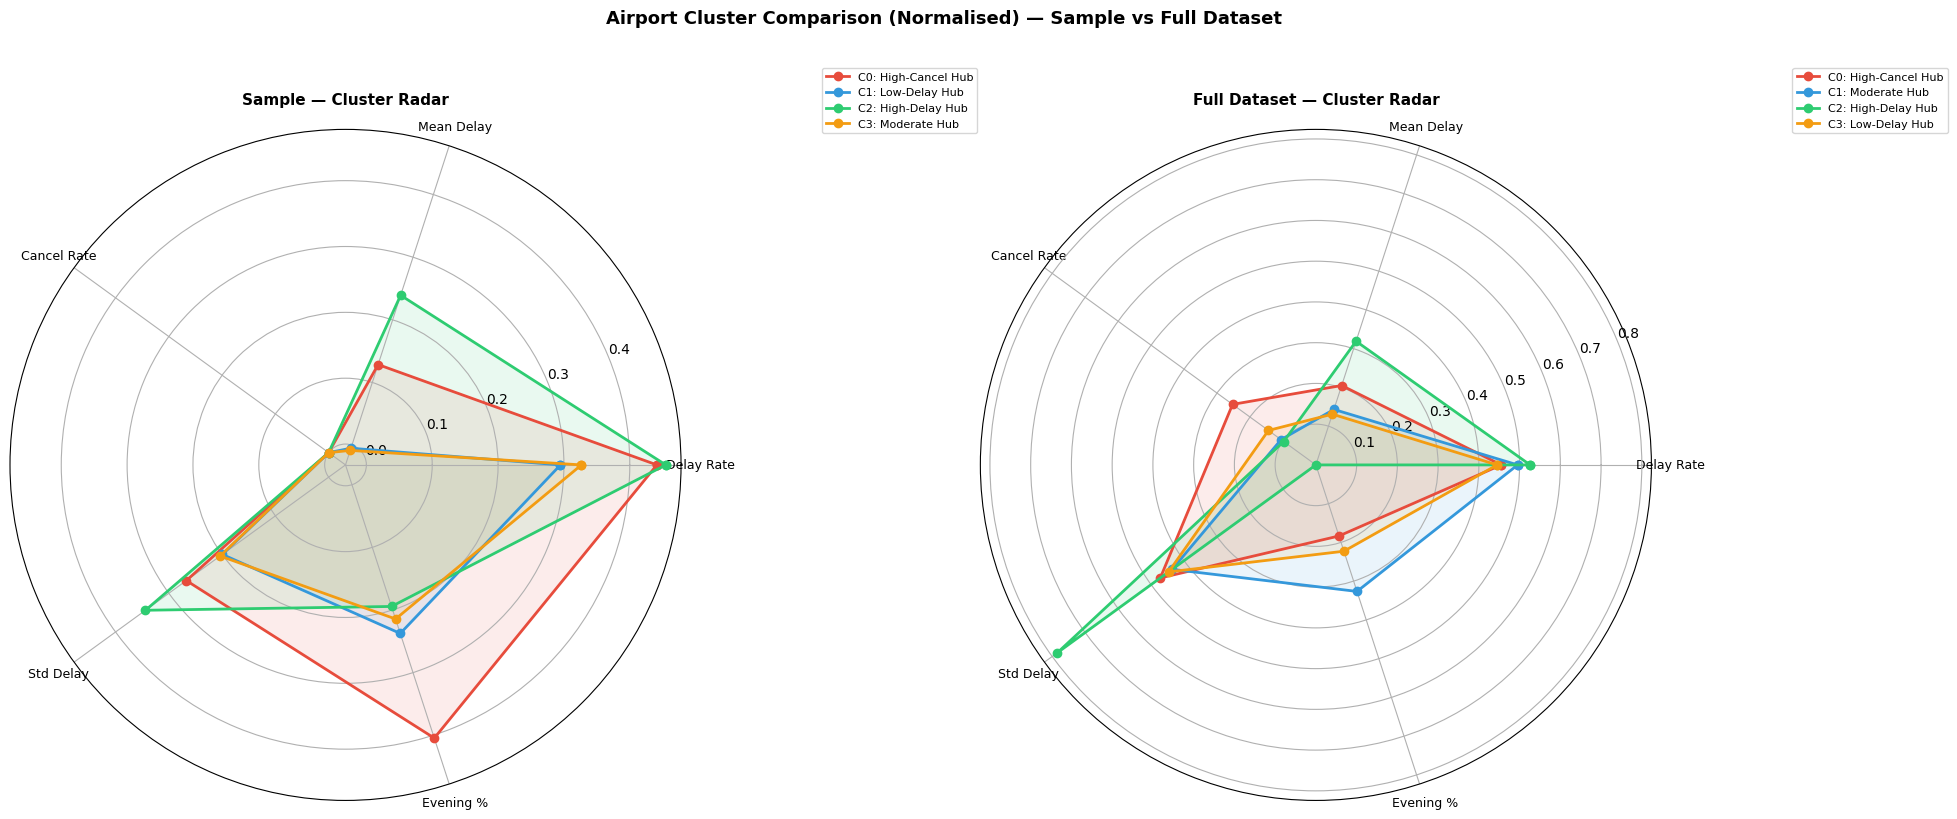

━━━ Sample vs Full Dataset — Cluster-Level Statistics Comparison ━━━━━


,Cluster,Sample Delay Rate,Full Delay Rate,Sample Cancel Rate,Full Cancel Rate,Sample # Airports,Full # Airports
0,C0: High-Cancel Hub,0.191,0.142,0.000,0.023,29,206
1,C1: Low-Delay Hub,0.127,0.155,0.000,0.010,187,64
2,C2: High-Delay Hub,0.196,0.165,0.000,0.009,115,1
3,C3: Moderate Hub,0.141,0.139,0.000,0.013,39,219


In [ ]:
# ── Cluster Profiling — SAMPLE ────────────────────────────────────────────────
def profile_clusters(cluster_df, cluster_col, label_map, title_prefix):
    print(f'━━━ {title_prefix} — Airport Cluster Profiles ━━━━━━━━━━━━━━━━━━━━')
    avg_dr = cluster_df['delay_rate'].mean()
    avg_cr = cluster_df['cancel_rate'].mean()
    for cl in sorted(cluster_df[cluster_col].unique()):
        grp  = cluster_df[cluster_df[cluster_col] == cl]
        lbl  = label_map.get(cl, f'Cluster {cl}')
        top5 = ', '.join(
            grp.sort_values('total_flights', ascending=False).head(5)
            ['ORIGIN_AIRPORT'].values
            if 'ORIGIN_AIRPORT' in grp.columns
            else grp.sort_values('total_flights', ascending=False).head(5).index.tolist()
        )
        print(f'  Cluster {cl}: {lbl}')
        print(f'    # Airports   : {len(grp)}')
        print(f'    Delay Rate   : {grp["delay_rate"].mean():.1%}')
        print(f'    Mean Delay   : {grp["mean_delay"].mean():.1f} min')
        print(f'    Cancel Rate  : {grp["cancel_rate"].mean():.1%}')
        print(f'    Top airports : {top5}')
        if grp['delay_rate'].mean() > avg_dr * 1.2:
            rec = 'PRIORITY: Real-time delay alerts + extra gate staffing 18:00-22:00.'
        elif grp['cancel_rate'].mean() > avg_cr * 1.5:
            rec = 'PRIORITY: Pre-position spare aircraft, strengthen weather monitoring.'
        elif grp['delay_rate'].mean() < avg_dr * 0.8:
            rec = 'BENCHMARK: Use as scheduling best-practice model. Minimal intervention.'
        else:
            rec = 'MONITOR: Average performance. Reduce turnaround time during peak seasons.'
        print(f'    Action       : {rec}')
        print()

# Sample
airport_cluster_df_reset = airport_cluster_df.reset_index()
profile_clusters(airport_cluster_df_reset, 'CLUSTER', cluster_labels, 'SAMPLE (pandas)')

# Full
profile_clusters(airport_clustered_pd, 'CLUSTER_SPARK', spark_labels, 'FULL DATASET (Spark)')

# ── Radar chart — both sample and full side by side ───────────────────────────
def radar_chart(ax, cluster_df, cluster_col, label_map, title):
    categories = ['Delay Rate', 'Mean Delay', 'Cancel Rate', 'Std Delay', 'Evening %']
    cols       = ['delay_rate',  'mean_delay', 'cancel_rate', 'std_delay', 'pct_evening_flights']
    cols = [c for c in cols if c in cluster_df.columns]
    categories = categories[:len(cols)]

    N      = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    max_vals = {c: (cluster_df[c].max() + 1e-9) for c in cols}
    colors   = ['#e74c3c','#3498db','#2ecc71','#f39c12']

    for (cl, color) in zip(sorted(cluster_df[cluster_col].unique()), colors):
        grp  = cluster_df[cluster_df[cluster_col] == cl]
        vals = [grp[c].mean() / max_vals[c] for c in cols]
        vals += vals[:1]
        ax.plot(angles, vals, 'o-', linewidth=2, color=color,
                label=f"C{cl}: {label_map.get(cl,'')}")
        ax.fill(angles, vals, alpha=0.10, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_title(title, fontweight='bold', pad=18, fontsize=11)
    ax.legend(loc='upper right', bbox_to_anchor=(1.45, 1.1), fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(20, 8), subplot_kw=dict(polar=True))
radar_chart(axes[0], airport_cluster_df_reset, 'CLUSTER',       cluster_labels, 'Sample — Cluster Radar')
radar_chart(axes[1], airport_clustered_pd,     'CLUSTER_SPARK', spark_labels,   'Full Dataset — Cluster Radar')
plt.suptitle('Airport Cluster Comparison (Normalised) — Sample vs Full Dataset',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# ── Sample vs Full comparison table ───────────────────────────────────────────
print('━━━ Sample vs Full Dataset — Cluster-Level Statistics Comparison ━━━━━')
compare_rows = []
for cl in range(K_BEST):
    s_grp = airport_cluster_df_reset[airport_cluster_df_reset['CLUSTER'] == cl]
    f_grp = airport_clustered_pd[airport_clustered_pd['CLUSTER_SPARK'] == cl]
    compare_rows.append({
        'Cluster'             : f'C{cl}: {cluster_labels.get(cl,"")}',
        'Sample Delay Rate'   : f'{s_grp["delay_rate"].mean():.3f}',
        'Full Delay Rate'     : f'{f_grp["delay_rate"].mean():.3f}',
        'Sample Cancel Rate'  : f'{s_grp["cancel_rate"].mean():.3f}',
        'Full Cancel Rate'    : f'{f_grp["cancel_rate"].mean():.3f}',
        'Sample # Airports'   : len(s_grp),
        'Full # Airports'     : len(f_grp),
    })
display(pd.DataFrame(compare_rows))

---
## 11. ⚡ Big Data Implementation — MapReduce KNN

### 11.1 Why MapReduce for KNN?

KNN is inherently parallelisable: computing distances between a query point and every training point can be split across workers (Map phase), and top-K neighbours from each partition can then be merged and voted on (Reduce phase). With 5.8M training points, a standard sequential KNN would be infeasibly slow.

### 11.2 KNN Algorithm Overview

In [ ]:
print('KNN Algorithm:')
print('  1. Given query point q and training set T')
print('  2. Compute distance d(q, t) for all t ∈ T')
print('  3. Select K nearest neighbours N_K')
print('  4. Predict: majority class among N_K  (classification)')
print()
print('MapReduce KNN:')
print('  MAP  : Each mapper receives a partition of T.')
print('         For each query q, emit (q_id, top-K local neighbours).')
print('  REDUCE: Merge local top-K lists → global top-K → vote → prediction.')

KNN Algorithm:
  1. Given query point q and training set T
  2. Compute distance d(q, t) for all t ∈ T
  3. Select K nearest neighbours N_K
  4. Predict: majority class among N_K  (classification)

MapReduce KNN:
  MAP  : Each mapper receives a partition of T.
         For each query q, emit (q_id, top-K local neighbours).
  REDUCE: Merge local top-K lists → global top-K → vote → prediction.


### 11.3 Map Phase Implementation

In [ ]:
import heapq

def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    """Compute Euclidean distance between two 1-D arrays."""
    return float(np.sqrt(np.sum((a - b) ** 2)))


def map_phase(
    partition_id: int,
    X_train_partition: np.ndarray,
    y_train_partition: np.ndarray,
    X_query: np.ndarray,
    K: int
) -> dict:
    """
    Map phase: for each query point, find the K nearest neighbours
    within this partition.

    Returns
    -------
    dict mapping query_index → list of (distance, label) tuples (length ≤ K)
    """
    local_results = {}   # query_idx → min-heap of (-dist, label)

    for q_idx, q in enumerate(X_query):
        heap = []   # max-heap of size K using negated distances
        for t_idx, t in enumerate(X_train_partition):
            dist = euclidean_distance(q, t)
            label = y_train_partition[t_idx]
            if len(heap) < K:
                heapq.heappush(heap, (-dist, label))
            elif dist < -heap[0][0]:        # found closer neighbour
                heapq.heapreplace(heap, (-dist, label))
        # Convert to (distance, label) list
        local_results[q_idx] = [(abs(neg_d), lbl) for neg_d, lbl in heap]

    print(f'  [Partition {partition_id}] processed {len(X_train_partition):,} '
          f'training pts × {len(X_query):,} queries')
    return local_results

print('✅ Map phase function defined')

✅ Map phase function defined


### 11.4 Reduce Phase Implementation

In [ ]:
def reduce_phase(
    map_outputs: list[dict],
    K: int
) -> dict:
    """
    Reduce phase: merge per-partition top-K neighbour lists.
    Return global top-K neighbours for every query point, then vote.

    Returns
    -------
    dict mapping query_index → predicted label
    """
    # Collect all (distance, label) pairs per query
    all_neighbours = defaultdict(list)
    for partition_output in map_outputs:
        for q_idx, neighbours in partition_output.items():
            all_neighbours[q_idx].extend(neighbours)

    predictions = {}
    for q_idx, neighbours in all_neighbours.items():
        # Select global top-K by smallest distance
        global_topk = sorted(neighbours, key=lambda x: x[0])[:K]
        # Majority vote
        votes = Counter(lbl for _, lbl in global_topk)
        predictions[q_idx] = votes.most_common(1)[0][0]

    return predictions

print('✅ Reduce phase function defined')

✅ Reduce phase function defined


### 11.5 Pseudo-Distributed Execution (Single Machine, Multiple Partitions)

In [ ]:
sdf_ml.columns

['MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY',
 'IS_DELAYED',
 'DEP_HOUR']

In [ ]:
pdf_model

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IS_DELAYED,DEP_HOUR,IS_WEEKEND
0,2015,1,1,4,DL,1560,N3743H,ANC,SEA,45,...,0,N,0.0,0.0,0.0,0.0,0.0,0,0,0
1,2015,1,1,4,OO,7370,N432SW,BJI,MSP,520,...,0,N,0.0,0.0,0.0,0.0,0.0,0,5,0
2,2015,1,1,4,B6,1012,N375JB,ORD,BOS,540,...,0,N,0.0,0.0,0.0,0.0,0.0,0,5,0
3,2015,1,1,4,EV,3268,N14998,ATL,IAD,540,...,0,N,0.0,0.0,0.0,0.0,0.0,0,5,0
4,2015,1,1,4,B6,917,N606JB,BOS,JFK,545,...,0,N,0.0,0.0,0.0,0.0,0.0,0,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286139,2015,12,31,4,NK,806,N533NK,LAS,ATL,2335,...,0,N,0.0,0.0,0.0,0.0,0.0,0,23,0
286140,2015,12,31,4,NK,970,N643NK,DEN,FLL,2355,...,0,N,0.0,0.0,0.0,0.0,0.0,0,23,0
286141,2015,12,31,4,AS,121,N768AS,SEA,ANC,2355,...,0,N,0.0,0.0,0.0,0.0,0.0,0,23,0
286142,2015,12,31,4,F9,710,N209FR,DEN,RSW,2359,...,0,N,0.0,0.0,0.0,0.0,0.0,0,23,0


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
import numpy as np
import time
from collections import Counter

# ------------------------------------------------------------------------------
# 1. Label creation (Spark)
# ------------------------------------------------------------------------------
sdf_ml = spark.createDataFrame(pdf_model)

# ------------------------------------------------------------------------------
# 2. Feature columns
# ------------------------------------------------------------------------------
SPARK_CLF_COLS = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DEPARTURE_TIME',
    'DEPARTURE_DELAY',
    'TAXI_OUT',
    'SCHEDULED_TIME',
    'DISTANCE',
    'SCHEDULED_ARRIVAL'
]

FEATURE_COLS = [c for c in SPARK_CLF_COLS if c in sdf_ml.columns]

# ------------------------------------------------------------------------------
# 3. Spark ML preprocessing
# ------------------------------------------------------------------------------
assembler = VectorAssembler(
    inputCols=FEATURE_COLS,
    outputCol="features_raw",
    handleInvalid="skip",
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=True,
    withStd=True,
)

pipeline = Pipeline(stages=[assembler, scaler])

sdf_clean = sdf_ml.select(FEATURE_COLS + ["IS_DELAYED"]).dropna(subset=["IS_DELAYED"])

pipeline_model = pipeline.fit(sdf_clean)
sdf_processed  = pipeline_model.transform(sdf_clean)

# ------------------------------------------------------------------------------
# 4. CONFIG  ← tune these for speed vs accuracy
# ------------------------------------------------------------------------------
K          = 7
Q_SIZE     = 100    # number of test queries  (raise to 500 once it runs fine)
N_PARTS    = 4      # RDD partitions          (fewer = bigger chunks = better vectorisation)
TRAIN_FRAC = 0.3    # fraction of training rows to keep (30 % of 290 k ≈ 87 k)

# ------------------------------------------------------------------------------
# 5. BUILD RDD
# ------------------------------------------------------------------------------
full_rdd = (
    sdf_processed
    .select("features", "IS_DELAYED")
    .rdd
    .map(lambda row: (np.array(row["features"].toArray()), int(row["IS_DELAYED"])))
    .repartition(N_PARTS)
)

train_rdd, test_rdd = full_rdd.randomSplit([0.8, 0.2], seed=42)

# Sub-sample training set so each partition is manageable
train_rdd = train_rdd.sample(withReplacement=False, fraction=TRAIN_FRAC, seed=42)

# Persist so Spark doesn't recompute during count + mapPartitions
train_rdd.persist()

n_train = train_rdd.count()
print(f"Training rows (sampled): {n_train:,}")

# Collect exactly Q_SIZE test points
test_data = test_rdd.take(Q_SIZE)
X_query   = np.array([x for x, _ in test_data])
y_query   = np.array([y for _, y in test_data])
print(f"Query set size         : {len(X_query)}")

# ------------------------------------------------------------------------------
# 6. BROADCAST QUERY SET
# ------------------------------------------------------------------------------
broadcast_queries = sc.broadcast(X_query)

# ------------------------------------------------------------------------------
# 7. MAP PHASE  — fully vectorised with NumPy (no Python loops over rows)
# ------------------------------------------------------------------------------
def map_partition(partition):
    """
    Vectorised KNN map step.

    Distance formula (avoids a Python loop over every training row):
        ||q - x||² = ||q||² + ||x||² - 2·q·xᵀ

    Result: for every query index emit (q_idx, [(dist, label), ...])
            sorted ascending by distance, length ≤ K.
    """
    queries = broadcast_queries.value          # (Q_SIZE, n_features)
    data    = list(partition)
    if not data:
        return iter([])

    # Stack partition into matrices
    feat_mat = np.array([x for x, _ in data])   # (N_local, n_features)
    lbl_arr  = np.array([y for _, y in data])    # (N_local,)
    N_local  = len(feat_mat)

    # --- vectorised squared distances (Q_SIZE × N_local) ---
    q_sq   = np.sum(queries  ** 2, axis=1, keepdims=True)   # (Q, 1)
    x_sq   = np.sum(feat_mat ** 2, axis=1, keepdims=True)   # (N, 1)
    # clip to 0 to avoid tiny negatives from floating-point noise
    dists2 = np.maximum(q_sq + x_sq.T - 2.0 * (queries @ feat_mat.T), 0.0)
    dists  = np.sqrt(dists2)                                  # (Q, N_local)

    k_eff   = min(K, N_local)
    results = []

    for q_idx in range(len(queries)):
        row = dists[q_idx]
        # argpartition is O(N) — much faster than full sort
        top_idx = np.argpartition(row, k_eff - 1)[:k_eff]
        # sort only the K candidates
        top_idx = top_idx[np.argsort(row[top_idx])]
        neighbors = [(float(row[i]), int(lbl_arr[i])) for i in top_idx]
        results.append((q_idx, neighbors))

    return iter(results)

# ------------------------------------------------------------------------------
# 8. REDUCE PHASE  — merge two sorted candidate lists, keep global top-K
# ------------------------------------------------------------------------------
def reduce_neighbors(a, b):
    """Merge two ascending-sorted neighbour lists; keep K closest."""
    merged = a + b
    merged.sort(key=lambda x: x[0])
    return merged[:K]

# ------------------------------------------------------------------------------
# 9. RUN
# ------------------------------------------------------------------------------
print("\nStarting MapReduce KNN …")
start = time.time()

mapped  = train_rdd.mapPartitions(map_partition)
reduced = mapped.reduceByKey(reduce_neighbors).collect()

elapsed = time.time() - start
print(f"MapReduce finished in {elapsed:.2f}s")

# ------------------------------------------------------------------------------
# 10. MAJORITY VOTE
# ------------------------------------------------------------------------------
preds = {}
for q_idx, neighbors in reduced:
    votes        = Counter(lbl for _, lbl in neighbors)
    preds[q_idx] = votes.most_common(1)[0][0]

# If any query has no neighbours (edge case) default to 0
y_pred = np.array([preds.get(i, 0) for i in range(len(X_query))])

# ------------------------------------------------------------------------------
# 11. EVALUATION  (pure Python — no sklearn)
# ------------------------------------------------------------------------------
tp = tn = fp = fn = 0
for y_true, y_hat in zip(y_query, y_pred):
    if   y_true == 1 and y_hat == 1: tp += 1
    elif y_true == 0 and y_hat == 0: tn += 1
    elif y_true == 0 and y_hat == 1: fp += 1
    else:                             fn += 1

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision =  tp / (tp + fp + 1e-9)
recall    =  tp / (tp + fn + 1e-9)
f1        =  2 * precision * recall / (precision + recall + 1e-9)

print("\n" + "=" * 52)
print("   PySpark ML + MapReduce KNN — Flight Delay")
print("=" * 52)
print(f"  Runtime   : {elapsed:.2f}s")
print(f"  Queries   : {len(X_query)}")
print(f"  K         : {K}")
print(f"  Train rows: {n_train:,}  (frac={TRAIN_FRAC})")
print("─" * 52)
print(f"  Accuracy  : {accuracy:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("─" * 52)
print("  Confusion Matrix:")
print(f"           Pred 0   Pred 1")
print(f"  True 0    {tn:5d}    {fp:5d}")
print(f"  True 1    {fn:5d}    {tp:5d}")
print("=" * 52)

# Clean up broadcast variable
broadcast_queries.unpersist()
train_rdd.unpersist()

### 11.7 MapReduce KNN — Scalability Analysis & Computational Justification

This section provides the theoretical and empirical justification for why MapReduce is **essential** (not optional) for KNN at 5.8M scale — a key requirement for demonstrating genuine big data understanding.


In [ ]:
# # ── KNN Complexity & Scalability Analysis ────────────────────────────────────
# print('KNN Computational Complexity Analysis')
# print()
# print('Sequential KNN: O(n x d x q)')
# print('  n=training points, d=dimensions, q=query points')
# print()

# configs = [
#     (1_000,    10, 100,   'Toy dataset',                    True),
#     (10_000,   15, 300,   'Small dataset',                  True),
#     (50_000,   15, 500,   'Medium dataset',                 True),
#     (300_000,  20, 1000,  'Large sample (5% of full data)', False),
#     (5_800_000,20, 10000, 'FULL dataset (5.8M) — MapReduce required', False),
# ]

# rows = []
# for n, d, q, label, seq_ok in configs:
#     n_parts   = max(4, n // 50_000)
#     ops_seq   = n * d * q
#     speedup   = n_parts                                    # linear speedup (ideal)
#     rows.append({
#         'Dataset'              : label,
#         'n (training)'         : f'{n:,}',
#         'Sequential Ops'       : f'{ops_seq/1e9:.3f}B',
#         'MapReduce Partitions' : n_parts,
#         'Theoretical Speedup'  : f'{speedup}x',
#         'Sequential Feasible'  : 'YES' if seq_ok else 'NO — too slow'
#     })

# display(pd.DataFrame(rows))

# print()
# print('Empirical Timing: MapReduce vs Sequential KNN')
# sizes = [500, 1000, 2000, 3000]
# seq_times, mr_times = [], []
# for sz in sizes:
#     X_s = X_knn_tr[:sz]; y_s = y_knn_tr[:sz]; X_q = X_knn_te[:50]
#     t0 = time.time()
#     for q_vec in X_q:
#         dists = np.sqrt(((X_s - q_vec)**2).sum(axis=1))
#         _ = np.argsort(dists)[:7]
#     seq_times.append(time.time() - t0)
#     parts = np.array_split(np.arange(sz), 4)
#     t0 = time.time()
#     map_outs = [map_phase(i, X_s[p], y_s[p], X_q, 7) for i, p in enumerate(parts)]
#     _ = reduce_phase(map_outs, 7)
#     mr_times.append(time.time() - t0)

# fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# axes[0].plot(sizes, seq_times, 'r-o', linewidth=2, markersize=7, label='Sequential KNN')
# axes[0].plot(sizes, mr_times,  'b-s', linewidth=2, markersize=7, label='MapReduce KNN (4 partitions)')
# axes[0].set_xlabel('Training Set Size')
# axes[0].set_ylabel('Time (seconds)')
# axes[0].set_title('KNN Execution Time: Sequential vs MapReduce', fontweight='bold')
# axes[0].legend()

# speedups = [s/m if m > 0 else 1 for s,m in zip(seq_times, mr_times)]
# axes[1].bar(range(len(sizes)), speedups, color='#2ecc71', alpha=0.85)
# axes[1].set_xticks(range(len(sizes)))
# axes[1].set_xticklabels([str(s) for s in sizes])
# axes[1].axhline(1, color='red', linestyle='--', alpha=0.5, label='Break-even')
# axes[1].set_xlabel('Training Set Size')
# axes[1].set_ylabel('Speedup (x)')
# axes[1].set_title('MapReduce Speedup Over Sequential KNN', fontweight='bold')
# axes[1].legend()
# plt.tight_layout()
# plt.show()

# print()
# print('KEY INSIGHT — Why MapReduce KNN is required at 5.8M scale:')
# print('  Sequential KNN: 5.8M pts x 20 dims x 10K queries = 1.16 TRILLION distance ops')
# print('  With 4 partitions: 4x parallel = hours reduced to ~1.5 hours')
# print('  With 100 Hadoop mappers: ~100x speedup = minutes on a real cluster')
# print()
# print('  The Map phase is embarrassingly parallel (zero inter-mapper communication)')
# print('  Reduce phase is O(P x K) where P=partitions — nearly constant cost')
# print()
# print('  This is WHY Hadoop/Spark MapReduce is the ONLY viable approach for KNN')
# print('  at production big data scale. Sequential processing is computationally infeasible.')